# COMP 9150 — RF & XGBoost Cross-Dataset Generalisation

Trains **Random Forest** and **XGBoost** on LycoS-IDS2017 and LycoS-Unicas-IDS2018 and evaluates all four train/test combinations:

| # | Train | Evaluate | Type |
|---|-------|----------|------|
| 1 | LycoS17 | LycoS17 | within-dataset |
| 2 | LycoS17 | LycoS18 | cross-dataset |
| 3 | LycoS18 | LycoS18 | within-dataset |
| 4 | LycoS18 | LycoS17 | cross-dataset |

**Features:** top-10 from Rosay et al. (same set used in EDA notebook).  
**Labels:** shared attack classes only for cross-dataset evaluation.  
**Methodology:** follows Cantone et al. (2024) — MinMax normalisation, grid search on a capped subset, retrain best estimator on full training set.

**Expected Google Drive layout:**
```
MyDrive/
├── utils/
│   ├── data_utils.py
│   └── viz_utils.py
└── datasets/
    ├── lycos_ids2017/
    │   ├── train_set.parquet
    │   ├── test_set.parquet
    │   └── crossval_set.parquet
    └── lycos_unicas_ids2018/
        ├── train_set.parquet
        ├── test_set.parquet
        └── crossval_set.parquet
```
Edit `UTILS_DIR` and `BASE` in §2 if your paths differ.

## 0 · Install dependencies

In [1]:
!pip install -q xgboost scikit-learn pandas pyarrow matplotlib seaborn

## 1 · Mount Google Drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 2 · Configuration & imports

In [3]:
import os
import sys
import warnings
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, matthews_corrcoef, f1_score, roc_auc_score
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', '{:.4f}'.format)

# ── Utils path ────────────────────────────────────────────────────────────────
# The utils/ folder should sit directly inside UTILS_DIR.
UTILS_DIR = '/content/drive/MyDrive/Colab Notebooks'
if UTILS_DIR not in sys.path:
    sys.path.insert(0, UTILS_DIR)

from utils.data_utils import load_dataset, prepare_Xy
from utils.viz_utils  import plot_confusion_matrix, plot_summary_bar_chart

# ── Dataset paths ─────────────────────────────────────────────────────────────
BASE = '/content/drive/MyDrive/Colab Notebooks/datasets'
DATA_ROOTS = {
    'LycoS17': os.path.join(BASE, 'lycos_ids2017'),
    'LycoS18': os.path.join(BASE, 'lycos_unicas_ids2018'),
}

# ── Label column ──────────────────────────────────────────────────────────────
LABEL_COL = 'Label'

# ── Grid-search cap ───────────────────────────────────────────────────────────
# Paper: grid search on a 20% random subset. Capped here for Colab feasibility.
GRID_SEARCH_CAP = 50_000
GRID_SEARCH_CV  = 3

RANDOM_STATE = 42

print('Configuration ready.')
# print(f'Features ({len(FEATURES)}):', FEATURES)

Configuration ready.


## 3 · Load datasets

`load_dataset` — defined in `utils/data_utils.py` — reads the three parquet splits,
concatenates train+crossval into the training pool, and returns `(train_df, test_df)`.

In [4]:
print('Loading LycoS-IDS2017 ...')
lycos17_train, lycos17_test = load_dataset(DATA_ROOTS['LycoS17'], 'LycoS17', LABEL_COL)

print('\nLoading LycoS-Unicas-IDS2018 ...')
lycos18_train, lycos18_test = load_dataset(DATA_ROOTS['LycoS18'], 'LycoS18', LABEL_COL)

print('\nClass counts — LycoS17 train:')
print(lycos17_train[LABEL_COL].value_counts().to_dict())
print('\nClass counts — LycoS18 train:')
print(lycos18_train[LABEL_COL].value_counts().to_dict())

Loading LycoS-IDS2017 ...
  LycoS17/train_set:    440,632 rows x 83 cols
  LycoS17/crossval_set:    220,312 rows x 83 cols
  LycoS17/test_set:    220,312 rows x 83 cols

Loading LycoS-Unicas-IDS2018 ...
  LycoS18/train_set:  3,691,266 rows x 78 cols
  LycoS18/crossval_set:  1,845,626 rows x 78 cols
  LycoS18/test_set:  1,845,644 rows x 78 cols

Class counts — LycoS17 train:
{'benign': 330474, 'dos_hulk': 119241, 'portscan': 119197, 'ddos': 71761, 'dos_goldeneye': 5073, 'dos_slowloris': 4255, 'dos_slowhttptest': 3649, 'ftp_patator': 3001, 'ssh_patator': 2218, 'webattack_bruteforce': 1020, 'bot': 550, 'webattack_xss': 489, 'webattack_sql_injection': 9, 'heartbleed': 7}

Class counts — LycoS18 train:
{'Benign': 2768446, 'DoS Hulk': 1352224, 'DDoS HOIC': 805783, 'DDoS LOIC-HTTP': 216996, 'FTP-Patator': 142725, 'DoS Slowhttptest': 79162, 'Bot': 72115, 'SSH-Patator': 69486, 'DoS GoldenEye': 20145, 'DoS Slowloris': 7705, 'DDoS LOIC-UDP': 1786, 'Web Attack - Brute Force': 195, 'Web Attack - XS

## 4 · Shared-class alignment

Cross-dataset experiments restrict both train and test to classes present in **both** datasets.
Within-dataset experiments use all classes of that dataset.

In [5]:
import re

# Normalize class labels for consistent comparison across datasets
def normalize_label(df, label_col):
    df[label_col] = df[label_col].astype(str).str.lower()
    # Replace spaces and hyphens with a single underscore
    df[label_col] = df[label_col].apply(lambda x: re.sub(r'[ \-]+', '_', x))
    # Handle known variations for better matching (e.g., 'webattack' vs 'web_attack')
    df[label_col] = df[label_col].str.replace('webattack', 'web_attack', regex=False)
    # If there are still multiple underscores due to combined replacements, reduce them to one
    df[label_col] = df[label_col].apply(lambda x: re.sub(r'_{2,}', '_', x))
    return df

lycos17_train = normalize_label(lycos17_train.copy(), LABEL_COL)
lycos17_test = normalize_label(lycos17_test.copy(), LABEL_COL)
lycos18_train = normalize_label(lycos18_train.copy(), LABEL_COL)
lycos18_test = normalize_label(lycos18_test.copy(), LABEL_COL)

classes_17 = set(lycos17_train[LABEL_COL].unique()) | set(lycos17_test[LABEL_COL].unique())
classes_18 = set(lycos18_train[LABEL_COL].unique()) | set(lycos18_test[LABEL_COL].unique())

SHARED_CLASSES = sorted(list(classes_17 & classes_18))
ONLY_17        = sorted(list(classes_17 - classes_18))
ONLY_18        = sorted(list(classes_18 - classes_17))

print(f'Shared classes ({len(SHARED_CLASSES)}): {SHARED_CLASSES}')
print(f'\nOnly in LycoS17 ({len(ONLY_17)}): {ONLY_17}')
print(f'Only in LycoS18 ({len(ONLY_18)}): {ONLY_18}')

# Add column alignment logic here
cols_17 = set(lycos17_train.columns)
cols_18 = set(lycos18_train.columns)

# Exclude the label and any non-feature columns (like IDs or timestamps if present)
NON_FEATURE_COLS = {LABEL_COL, 'flow_id', 'src_addr', 'src_port', 'dst_addr', 'dst_port', 'timestamp'}

ALL_FEATURES_17 = sorted(list(cols_17 - NON_FEATURE_COLS))
ALL_FEATURES_18 = sorted(list(cols_18 - NON_FEATURE_COLS))
SHARED_FEATURES = sorted(list((cols_17 & cols_18) - NON_FEATURE_COLS))

print(f"Features in LycoS17: {len(ALL_FEATURES_17)}")
print(f"Features in LycoS18: {len(ALL_FEATURES_18)}")
print(f"Shared features: {len(SHARED_FEATURES)}")

Shared classes (10): ['benign', 'bot', 'dos_goldeneye', 'dos_hulk', 'dos_slowhttptest', 'dos_slowloris', 'ftp_patator', 'ssh_patator', 'web_attack_sql_injection', 'web_attack_xss']

Only in LycoS17 (4): ['ddos', 'heartbleed', 'portscan', 'web_attack_bruteforce']
Only in LycoS18 (4): ['ddos_hoic', 'ddos_loic_http', 'ddos_loic_udp', 'web_attack_brute_force']
Features in LycoS17: 76
Features in LycoS18: 76
Shared features: 76


## 5 · Hyperparameter grids

Exact grids from Cantone et al. (2024), Table 2.

In [6]:
RF_PARAM_GRID = {
    'criterion'        : ['gini', 'entropy'],
    'max_depth'        : [None, 10],
    'min_samples_split': [4, 16],
    'max_features'     : [None, 'sqrt', 'log2'],
    'n_estimators'     : [10, 50],
}

XGB_PARAM_GRID = {
    'max_depth'       : [3, 6, 10],
    'n_estimators'    : [10, 50],
    'learning_rate'   : [0.1, 0.3],
    'booster'         : ['gbtree', "gblinear"], # Use tree-based models for tabular data
    'min_child_weight': [1, 2],
    'gamma'           : [0, 1],
    'random_state'    : [RANDOM_STATE],
    'n_jobs'          : [-1],
    'tree_method'     : ['auto'] # Ensuring compatibility with Colab's environment
}

print(f'RF  grid combinations : {2*2*2*3*2}')
print(f'XGB grid combinations : {3*2*3*2*3*3}')

RF  grid combinations : 48
XGB grid combinations : 324


## 6 · Training helpers

In [7]:
def grid_search_fit(estimator, param_grid, X_train, y_train,
                    cap=GRID_SEARCH_CAP, cv=GRID_SEARCH_CV):
    if len(X_train) > cap:
        rng = np.random.default_rng(RANDOM_STATE)
        idx = rng.choice(len(X_train), size=cap, replace=False)
        X_gs, y_gs = X_train[idx], y_train[idx]
        print(f'  Grid search on {cap:,} / {len(X_train):,} rows (capped)')
    else:
        X_gs, y_gs = X_train, y_train
        print(f'  Grid search on {len(X_train):,} rows (full)')

    # Re-encode labels to be strictly contiguous 0..n-1 for the grid-search
    # subset (rare classes may vanish from the cap, leaving gaps in the
    # integer sequence that XGBoost rejects).
    gs_le = LabelEncoder()
    y_gs_reenc = gs_le.fit_transform(y_gs)

    gs = GridSearchCV(
        estimator  = estimator,
        param_grid = param_grid,
        cv         = cv,
        scoring    = 'f1_macro',
        n_jobs     = -1,
        verbose    = 0,
    )
    gs.fit(X_gs, y_gs_reenc)
    print(f'  Best params : {gs.best_params_}')
    print(f'  Best CV F1  : {gs.best_score_:.4f}')

    # Retrain best estimator on the FULL training set with original labels
    # (full set always has all classes so labels are contiguous)
    best = gs.best_estimator_
    best.fit(X_train, y_train)
    return best


def evaluate(model, X_test, y_test, le, title=''):
    y_pred      = model.predict(X_test)
    mcc         = matthews_corrcoef(y_test, y_pred)
    f1          = f1_score(y_test, y_pred, average='macro', zero_division=0)

    # AUROC requires probability estimates. Use predict_proba if available,
    # fall back to decision_function, and skip gracefully if neither exists
    # (e.g. gblinear XGBoost with no probability calibration).
    auroc = float('nan')
    try:
        if hasattr(model, 'predict_proba'):
            y_prob = model.predict_proba(X_test)
        elif hasattr(model, 'decision_function'):
            y_prob = model.decision_function(X_test)
        else:
            raise AttributeError('No probability method available')

        n_classes = len(le.classes_)
        if n_classes == 2:
            auroc = roc_auc_score(y_test, y_prob[:, 1])
        else:
            # Filter out any -1 labels (unseen classes in cross-dataset eval)
            mask  = y_test >= 0
            auroc = roc_auc_score(
                y_test[mask], y_prob[mask],
                multi_class='ovr',
                average='macro',
                labels=list(range(n_classes)),
            )
    except Exception as e:
        print(f'  AUROC skipped: {e}')

    print(f'\n{"="*60}')
    print(f'  {title}')
    print(f'  MCC = {mcc:.4f}  |  Macro-F1 = {f1:.4f}  |  AUROC = {auroc:.4f}')
    print(f'{"="*60}')
    print(classification_report(
        y_test, y_pred,
        target_names=le.classes_,
        zero_division=0,
    ))
    return mcc, f1, auroc, y_pred


print('Training helpers defined.')

Training helpers defined.


## 7 · Define the four experiments

In [8]:
EXPERIMENTS = [
    {
        'id'            : 1,
        'label'         : 'Train LycoS17 -> Eval LycoS17 (within-dataset)',
        'train_df'      : lycos17_train,
        'test_df'       : lycos17_test,
        'shared_classes': None,
        'features'      : ALL_FEATURES_17, # Use all 17 features
    },
    {
        'id'            : 2,
        'label'         : 'Train LycoS17 -> Eval LycoS18 (cross-dataset)',
        'train_df'      : lycos17_train,
        'test_df'       : lycos18_test,
        'shared_classes': SHARED_CLASSES,
        'features'      : SHARED_FEATURES, # Use only shared features
    },
    {
        'id'            : 3,
        'label'         : 'Train LycoS18 -> Eval LycoS18 (within-dataset)',
        'train_df'      : lycos18_train,
        'test_df'       : lycos18_test,
        'shared_classes': None,
        'features'      : ALL_FEATURES_18, # Use all 18 features
    },
    {
        'id'            : 4,
        'label'         : 'Train LycoS18 -> Eval LycoS17 (cross-dataset)',
        'train_df'      : lycos18_train,
        'test_df'       : lycos17_test,
        'shared_classes': SHARED_CLASSES,
        'features'      : SHARED_FEATURES, # Use only shared features
    },
]

for e in EXPERIMENTS:
    tag = 'within' if e['shared_classes'] is None else 'cross'
    print(f"  [{e['id']}] [{tag:6s}] {e['label']}")

  [1] [within] Train LycoS17 -> Eval LycoS17 (within-dataset)
  [2] [cross ] Train LycoS17 -> Eval LycoS18 (cross-dataset)
  [3] [within] Train LycoS18 -> Eval LycoS18 (within-dataset)
  [4] [cross ] Train LycoS18 -> Eval LycoS17 (cross-dataset)


## 8 · Run all experiments

For each of the 4 train/test combinations:
1. `prepare_Xy` *(utils/data_utils.py)* — MinMax scale + integer-encode labels
2. Grid-search RF → retrain best params on full train set
3. Grid-search XGB → retrain best params on full train set
4. `evaluate` — MCC, Macro-F1, per-class classification report
5. `plot_confusion_matrix` *(utils/viz_utils.py)* — heatmap saved to PNG

> **Runtime note:** each grid search can take 5–15 min on Colab CPU.  
> Reduce `GRID_SEARCH_CAP` in §2 or switch to a GPU runtime if needed.


######################################################################
  EXPERIMENT 1: Train LycoS17 -> Eval LycoS17 (within-dataset)
######################################################################

[Preprocessing]
  Train: 660,944 rows | Test: 220,312 rows
  Classes (14): ['benign', 'bot', 'ddos', 'dos_goldeneye', 'dos_hulk', 'dos_slowhttptest', 'dos_slowloris', 'ftp_patator', 'heartbleed', 'portscan', 'ssh_patator', 'web_attack_bruteforce', 'web_attack_sql_injection', 'web_attack_xss']

[Random Forest - grid search]
  Grid search on 50,000 / 660,944 rows (capped)
  Best params : {'criterion': 'entropy', 'max_depth': None, 'max_features': 'sqrt', 'min_samples_split': 4, 'n_estimators': 10}
  Best CV F1  : 0.9005

  RF | Exp 1: Train LycoS17 -> Eval LycoS17 (within-dataset)
  MCC = 0.9978  |  Macro-F1 = 0.8610  |  AUROC = 0.9836
                          precision    recall  f1-score   support

                  benign       1.00      1.00      1.00    110158
                  

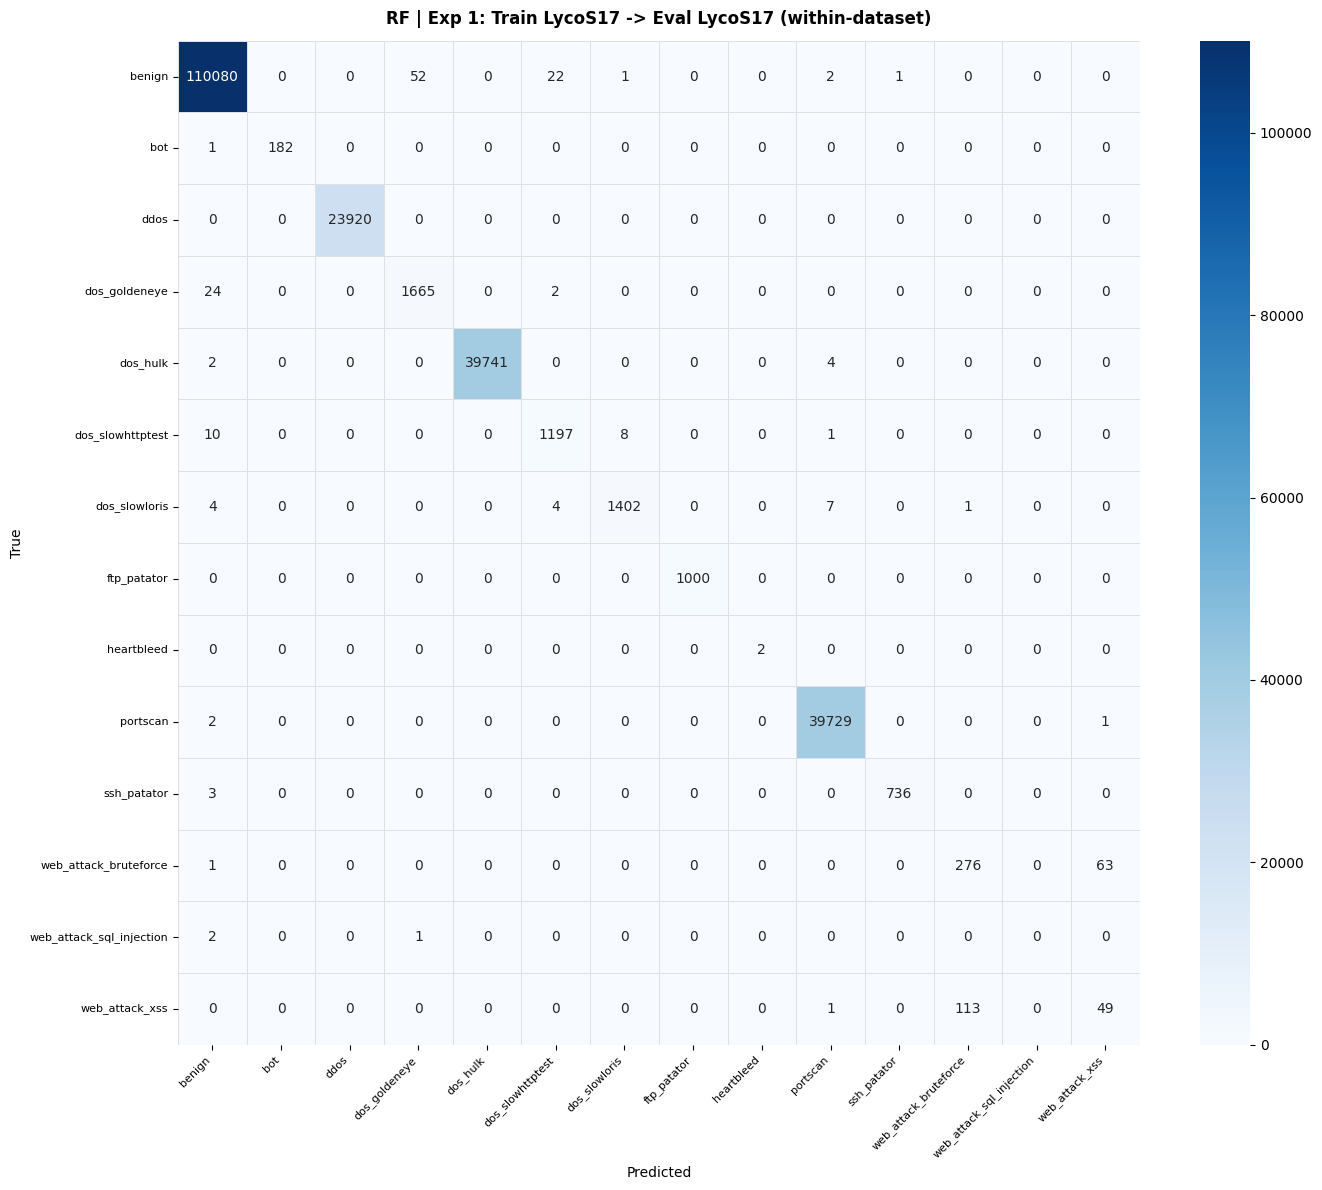


######################################################################
  EXPERIMENT 2: Train LycoS17 -> Eval LycoS18 (cross-dataset)
######################################################################

[Preprocessing]
  Train: 468,959 rows | Test: 1,504,055 rows
  Classes (10): ['benign', 'bot', 'dos_goldeneye', 'dos_hulk', 'dos_slowhttptest', 'dos_slowloris', 'ftp_patator', 'ssh_patator', 'web_attack_sql_injection', 'web_attack_xss']

[Random Forest - grid search]
  Grid search on 50,000 / 468,959 rows (capped)
  Best params : {'criterion': 'gini', 'max_depth': None, 'max_features': 'sqrt', 'min_samples_split': 4, 'n_estimators': 50}
  Best CV F1  : 0.9862

  RF | Exp 2: Train LycoS17 -> Eval LycoS18 (cross-dataset)
  MCC = 0.0427  |  Macro-F1 = 0.2355  |  AUROC = 0.7914
                          precision    recall  f1-score   support

                  benign       0.61      1.00      0.76    922822
                     bot       1.00      0.01      0.02     24039
           dos

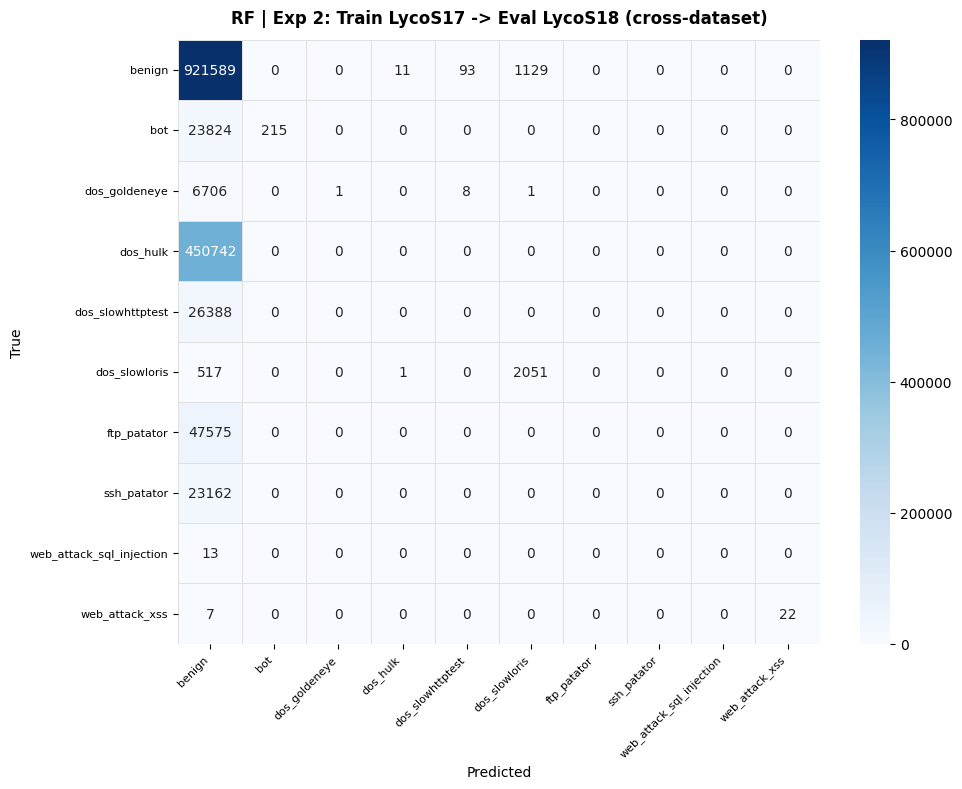


######################################################################
  EXPERIMENT 3: Train LycoS18 -> Eval LycoS18 (within-dataset)
######################################################################

[Preprocessing]
  Train: 5,536,892 rows | Test: 1,845,644 rows
  Classes (14): ['benign', 'bot', 'ddos_hoic', 'ddos_loic_http', 'ddos_loic_udp', 'dos_goldeneye', 'dos_hulk', 'dos_slowhttptest', 'dos_slowloris', 'ftp_patator', 'ssh_patator', 'web_attack_brute_force', 'web_attack_sql_injection', 'web_attack_xss']

[Random Forest - grid search]
  Grid search on 50,000 / 5,536,892 rows (capped)
  Best params : {'criterion': 'entropy', 'max_depth': 10, 'max_features': 'log2', 'min_samples_split': 4, 'n_estimators': 50}
  Best CV F1  : 0.8900

  RF | Exp 3: Train LycoS18 -> Eval LycoS18 (within-dataset)
  MCC = 0.9841  |  Macro-F1 = 0.9273  |  AUROC = 0.9993
                          precision    recall  f1-score   support

                  benign       1.00      1.00      1.00    922822

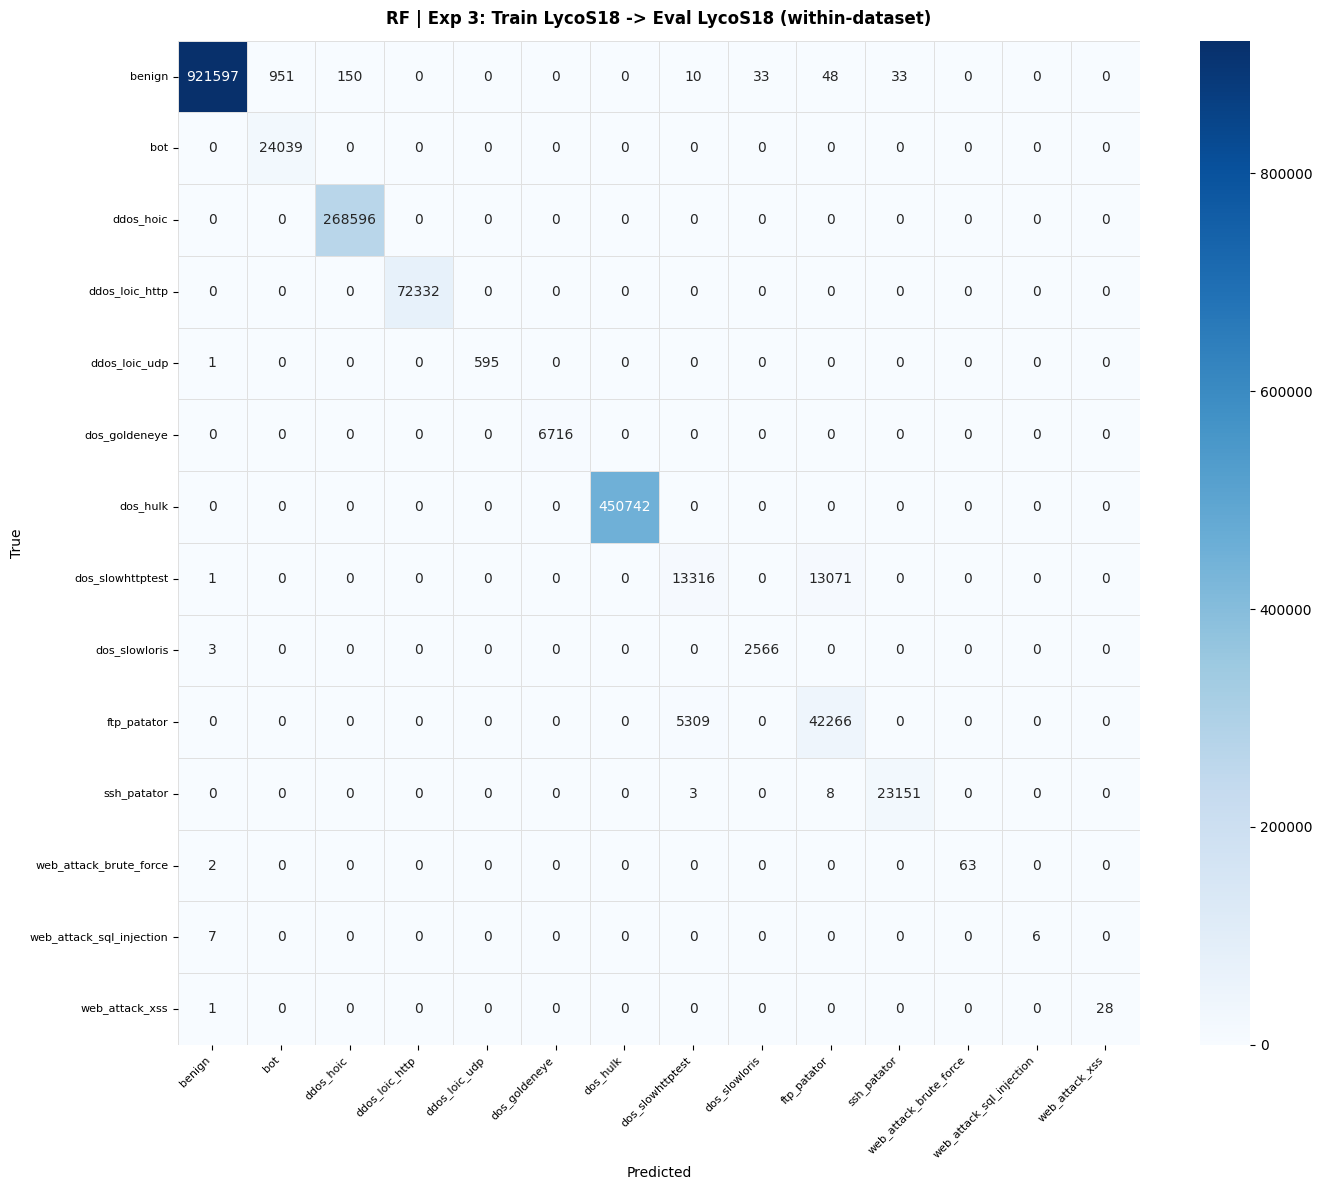


######################################################################
  EXPERIMENT 4: Train LycoS18 -> Eval LycoS17 (cross-dataset)
######################################################################

[Preprocessing]
  Train: 4,512,132 rows | Test: 156,318 rows
  Classes (10): ['benign', 'bot', 'dos_goldeneye', 'dos_hulk', 'dos_slowhttptest', 'dos_slowloris', 'ftp_patator', 'ssh_patator', 'web_attack_sql_injection', 'web_attack_xss']

[Random Forest - grid search]
  Grid search on 50,000 / 4,512,132 rows (capped)
  Best params : {'criterion': 'entropy', 'max_depth': None, 'max_features': 'sqrt', 'min_samples_split': 4, 'n_estimators': 10}
  Best CV F1  : 0.9243

  RF | Exp 4: Train LycoS18 -> Eval LycoS17 (cross-dataset)
  MCC = 0.1318  |  Macro-F1 = 0.1774  |  AUROC = 0.7133
                          precision    recall  f1-score   support

                  benign       0.71      1.00      0.83    110158
                     bot       0.00      0.00      0.00       183
         

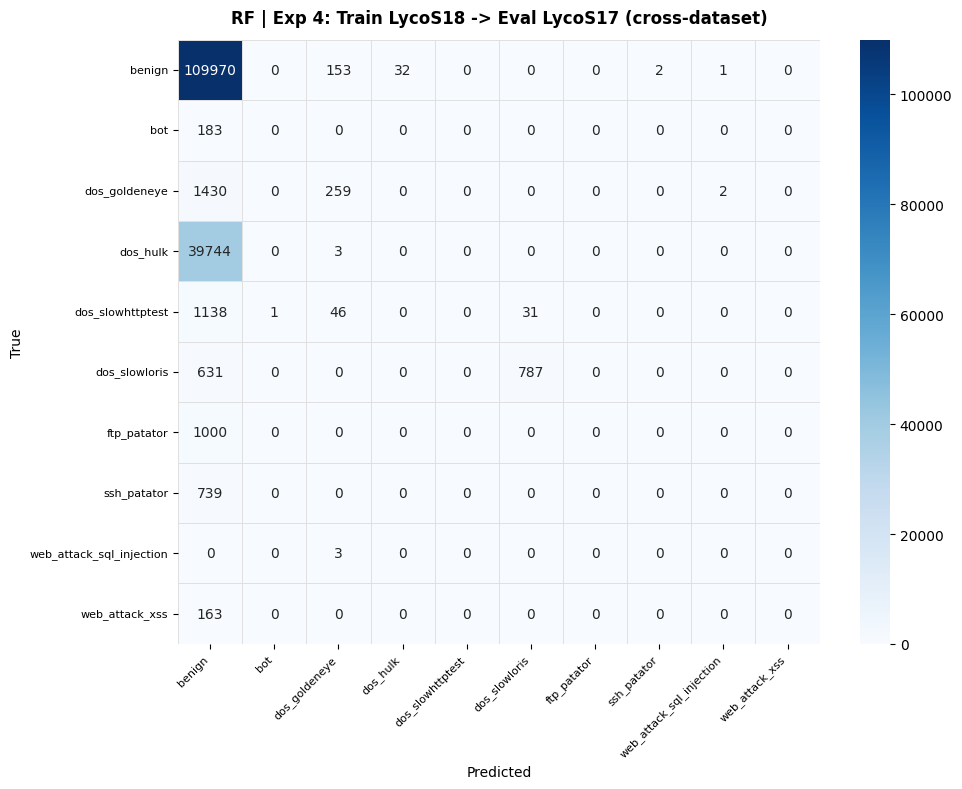

In [9]:
results = []

for exp in EXPERIMENTS:
    eid   = exp['id']
    title = exp['label']

    print(f'\n{"#"*70}')
    print(f'  EXPERIMENT {eid}: {title}')
    print(f'{"#"*70}')

    # ── Preprocess (utils/data_utils.py) ─────────────────────────────────────
    print('\n[Preprocessing]')
    X_train, X_test, y_train, y_test, le = prepare_Xy(
        train_df       = exp['train_df'],
        test_df        = exp['test_df'],
        features       = exp['features'],
        label_col      = LABEL_COL,
        shared_classes = exp['shared_classes'],
    )

    # ── Random Forest ─────────────────────────────────────────────────────────
    print('\n[Random Forest - grid search]')
    rf_base = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)
    rf_best = grid_search_fit(rf_base, RF_PARAM_GRID, X_train, y_train)

    rf_mcc, rf_f1, rf_auroc, rf_pred = evaluate(
        rf_best, X_test, y_test, le,
        title=f'RF | Exp {eid}: {title}',
    )
    plot_confusion_matrix(              # utils/viz_utils.py
        y_test, rf_pred, le,
        title=f'RF | Exp {eid}: {title}',
    )
    results.append({
        'Experiment' : eid,
        'Description': title,
        'Model'      : 'RF',
        'MCC'        : rf_mcc,
        'Macro-F1'   : rf_f1,
        'AUROC': rf_auroc,
    })


######################################################################
  EXPERIMENT 1: Train LycoS17 -> Eval LycoS17 (within-dataset)
######################################################################

[Preprocessing]
  Train: 660,944 rows | Test: 220,312 rows
  Classes (14): ['benign', 'bot', 'ddos', 'dos_goldeneye', 'dos_hulk', 'dos_slowhttptest', 'dos_slowloris', 'ftp_patator', 'heartbleed', 'portscan', 'ssh_patator', 'web_attack_bruteforce', 'web_attack_sql_injection', 'web_attack_xss']

[XGBoost - grid search]
  Grid search on 50,000 / 660,944 rows (capped)
  Best params : {'booster': 'gbtree', 'gamma': 0, 'learning_rate': 0.1, 'max_depth': 3, 'min_child_weight': 1, 'n_estimators': 10, 'n_jobs': -1, 'random_state': 42, 'tree_method': 'auto'}
  Best CV F1  : nan

  XGB | Exp 1: Train LycoS17 -> Eval LycoS17 (within-dataset)
  MCC = 0.9928  |  Macro-F1 = 0.7350  |  AUROC = 0.9957
                          precision    recall  f1-score   support

                  benign       0

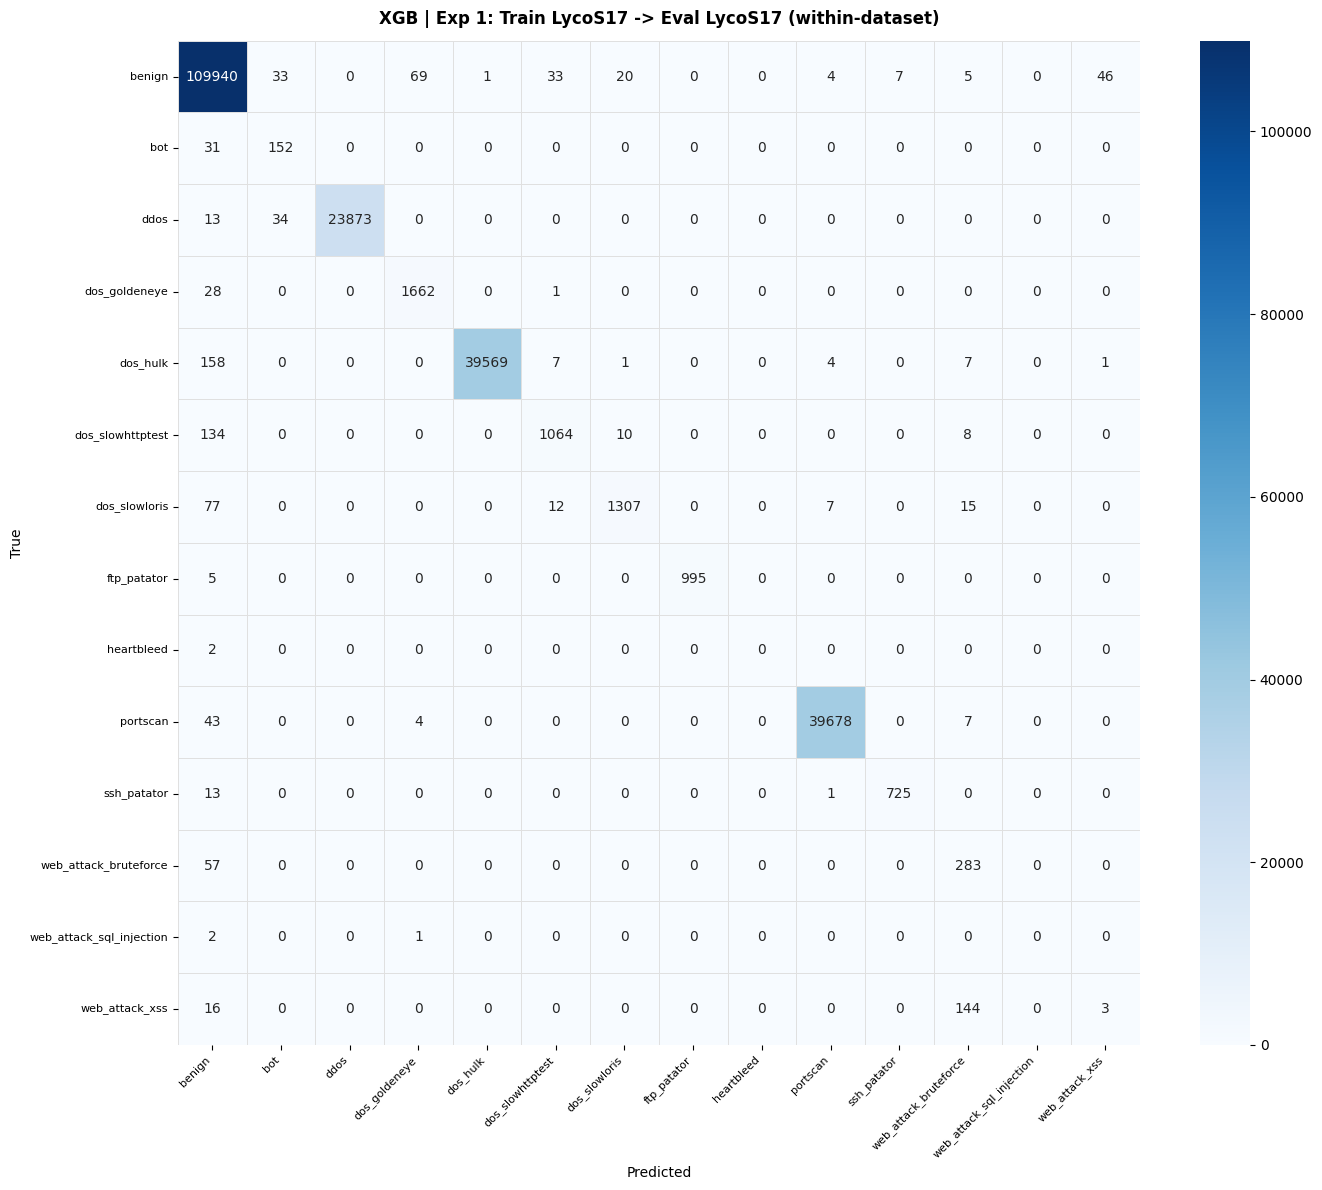


######################################################################
  EXPERIMENT 2: Train LycoS17 -> Eval LycoS18 (cross-dataset)
######################################################################

[Preprocessing]
  Train: 468,959 rows | Test: 1,504,055 rows
  Classes (10): ['benign', 'bot', 'dos_goldeneye', 'dos_hulk', 'dos_slowhttptest', 'dos_slowloris', 'ftp_patator', 'ssh_patator', 'web_attack_sql_injection', 'web_attack_xss']

[XGBoost - grid search]
  Grid search on 50,000 / 468,959 rows (capped)
  Best params : {'booster': 'gbtree', 'gamma': 0, 'learning_rate': 0.1, 'max_depth': 6, 'min_child_weight': 1, 'n_estimators': 50, 'n_jobs': -1, 'random_state': 42, 'tree_method': 'auto'}
  Best CV F1  : 0.9798

  XGB | Exp 2: Train LycoS17 -> Eval LycoS18 (cross-dataset)
  MCC = 0.0313  |  Macro-F1 = 0.1355  |  AUROC = 0.9383
                          precision    recall  f1-score   support

                  benign       0.61      1.00      0.76    922822
                     b

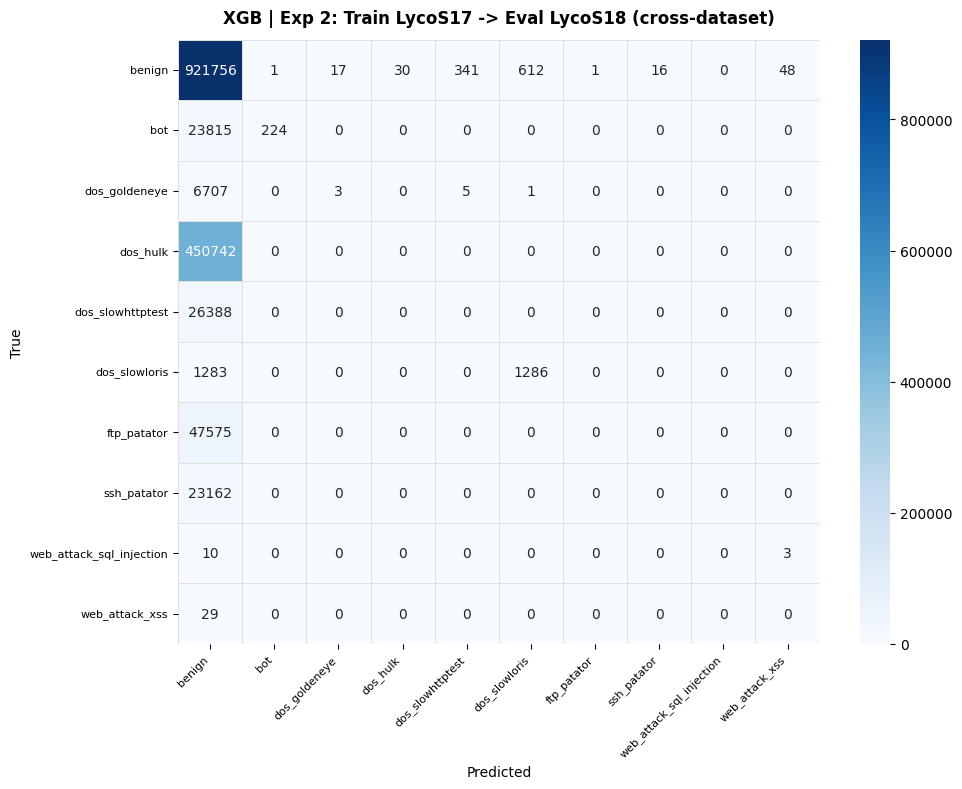


######################################################################
  EXPERIMENT 3: Train LycoS18 -> Eval LycoS18 (within-dataset)
######################################################################

[Preprocessing]
  Train: 5,536,892 rows | Test: 1,845,644 rows
  Classes (14): ['benign', 'bot', 'ddos_hoic', 'ddos_loic_http', 'ddos_loic_udp', 'dos_goldeneye', 'dos_hulk', 'dos_slowhttptest', 'dos_slowloris', 'ftp_patator', 'ssh_patator', 'web_attack_brute_force', 'web_attack_sql_injection', 'web_attack_xss']

[XGBoost - grid search]
  Grid search on 50,000 / 5,536,892 rows (capped)
  Best params : {'booster': 'gbtree', 'gamma': 0, 'learning_rate': 0.1, 'max_depth': 3, 'min_child_weight': 1, 'n_estimators': 10, 'n_jobs': -1, 'random_state': 42, 'tree_method': 'auto'}
  Best CV F1  : nan

  XGB | Exp 3: Train LycoS18 -> Eval LycoS18 (within-dataset)
  MCC = 0.9832  |  Macro-F1 = 0.7830  |  AUROC = 0.9979
                          precision    recall  f1-score   support

           

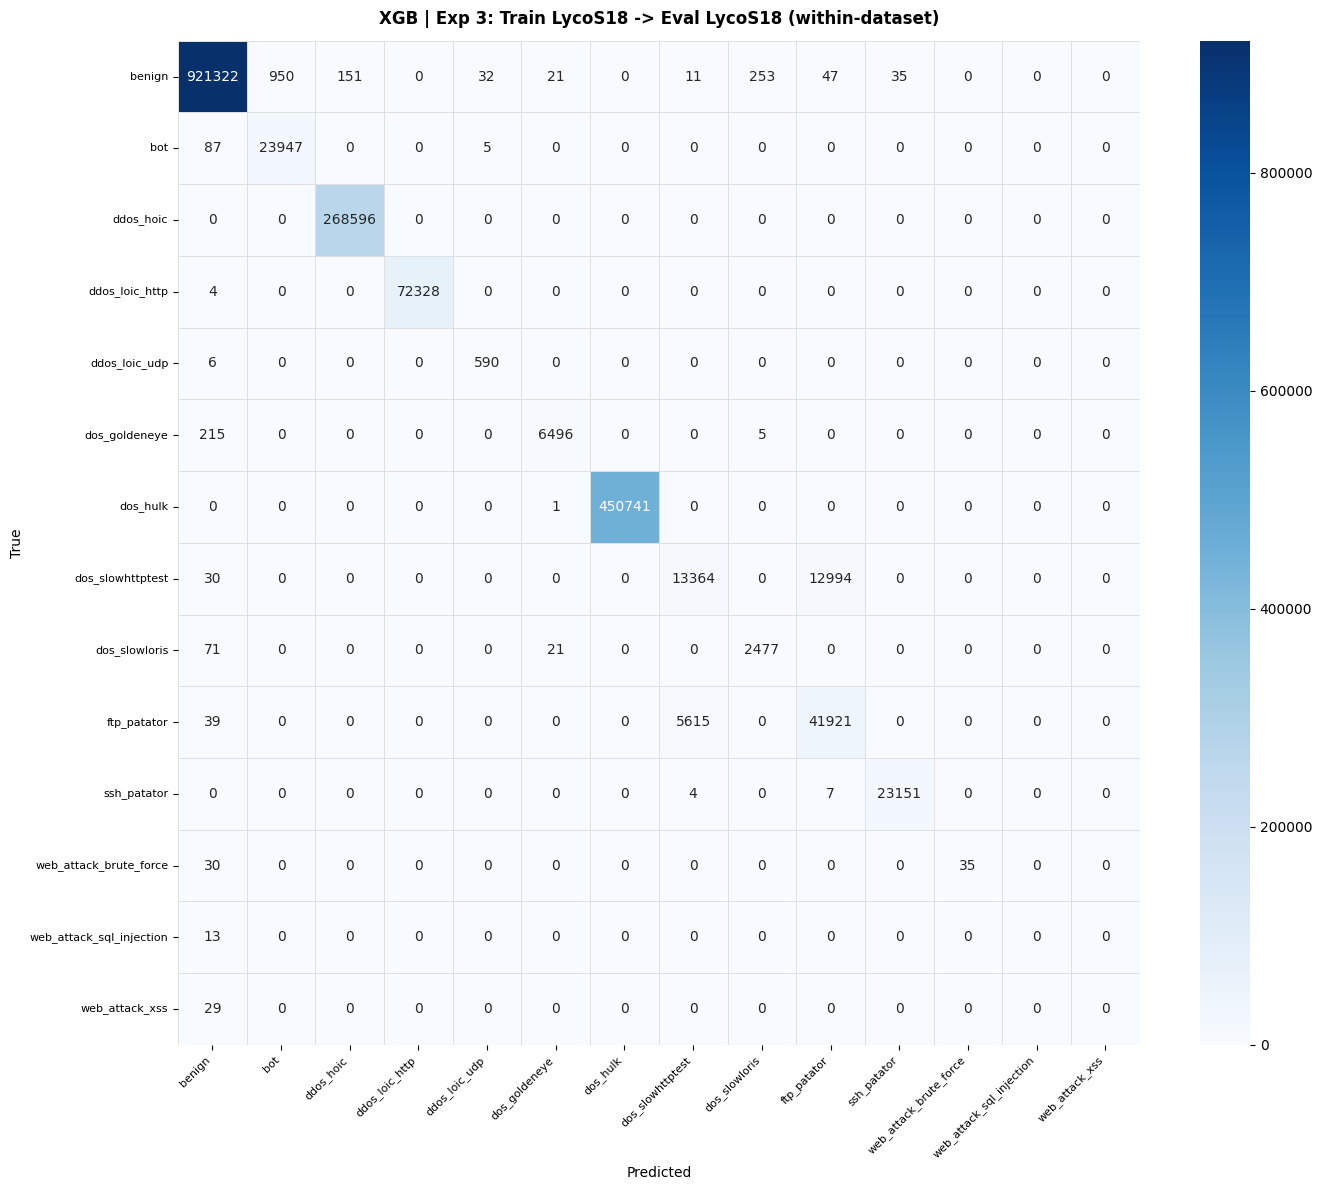


######################################################################
  EXPERIMENT 4: Train LycoS18 -> Eval LycoS17 (cross-dataset)
######################################################################

[Preprocessing]
  Train: 4,512,132 rows | Test: 156,318 rows
  Classes (10): ['benign', 'bot', 'dos_goldeneye', 'dos_hulk', 'dos_slowhttptest', 'dos_slowloris', 'ftp_patator', 'ssh_patator', 'web_attack_sql_injection', 'web_attack_xss']

[XGBoost - grid search]
  Grid search on 50,000 / 4,512,132 rows (capped)
  Best params : {'booster': 'gbtree', 'gamma': 0, 'learning_rate': 0.3, 'max_depth': 3, 'min_child_weight': 2, 'n_estimators': 50, 'n_jobs': -1, 'random_state': 42, 'tree_method': 'auto'}
  Best CV F1  : 0.9227

  XGB | Exp 4: Train LycoS18 -> Eval LycoS17 (cross-dataset)
  MCC = -0.1084  |  Macro-F1 = 0.1057  |  AUROC = 0.5084
                          precision    recall  f1-score   support

                  benign       0.65      0.68      0.67    110158
                   

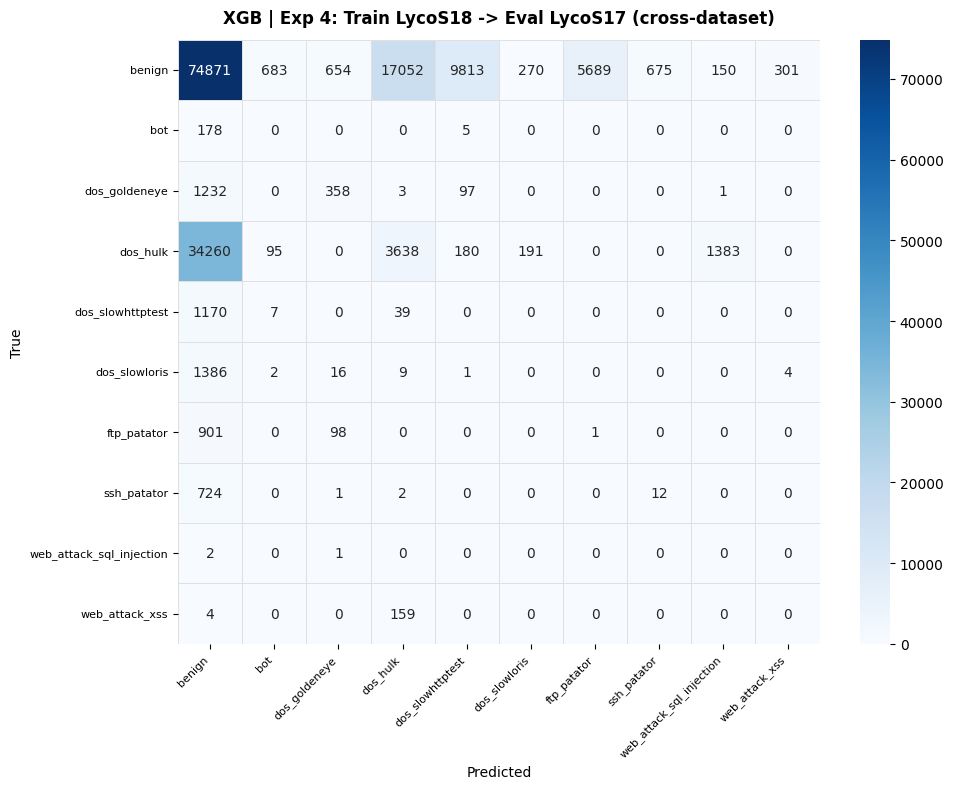


All experiments complete.


In [10]:
#results = []
for exp in EXPERIMENTS:
    eid   = exp['id']
    title = exp['label']

    print(f'\n{"#"*70}')
    print(f'  EXPERIMENT {eid}: {title}')
    print(f'{"#"*70}')

    # ── Preprocess (utils/data_utils.py) ─────────────────────────────────────
    print('\n[Preprocessing]')
    X_train, X_test, y_train, y_test, le = prepare_Xy(
        train_df       = exp['train_df'],
        test_df        = exp['test_df'],
        features       = exp['features'],
        label_col      = LABEL_COL,
        shared_classes = exp['shared_classes'],
    )

    # ── XGBoost ───────────────────────────────────────────────────────────────
    print('\n[XGBoost - grid search]')
    # Use use_label_encoder=False to avoid deprecation warnings in newer versions
    xgb_base = XGBClassifier(
      random_state = RANDOM_STATE,
      eval_metric  = 'mlogloss',
      n_jobs       = -1,
      verbosity    = 0,
      # num_class and objective are intentionally omitted —
      # XGBoost infers them automatically from y each time it fits,
      # avoiding contiguous-label errors across CV folds.
    )
    xgb_best = grid_search_fit(xgb_base, XGB_PARAM_GRID, X_train, y_train)

    xgb_mcc, xgb_f1, xgb_auroc, xgb_pred = evaluate(
        xgb_best, X_test, y_test, le,
        title=f'XGB | Exp {eid}: {title}',
    )

    plot_confusion_matrix(              # utils/viz_utils.py
        y_test, xgb_pred, le,
        title=f'XGB | Exp {eid}: {title}',
    )

    results.append({
        'Experiment' : eid,
        'Description': title,
        'Model'      : 'XGB',
        'MCC'        : xgb_mcc,
        'Macro-F1'   : xgb_f1,
        'AUROC': xgb_auroc,
    })

print('\nAll experiments complete.')

## 9 · Summary table

In [11]:
summary = pd.DataFrame(results)
summary['Type'] = summary['Experiment'].map({
    1: 'within-dataset',
    2: 'cross-dataset',
    3: 'within-dataset',
    4: 'cross-dataset',
})
summary = (
    summary[['Experiment', 'Type', 'Model', 'MCC', 'Macro-F1', 'AUROC', 'Description']]
    .sort_values(['Experiment', 'Model'])
    .reset_index(drop=True)
)
print(summary.to_string(index=False))
summary.to_csv('results_summary.csv', index=False)
print('\nSaved to results_summary.csv')

 Experiment           Type Model     MCC  Macro-F1  AUROC                                    Description
          1 within-dataset    RF  0.9978    0.8610 0.9836 Train LycoS17 -> Eval LycoS17 (within-dataset)
          1 within-dataset   XGB  0.9928    0.7350 0.9957 Train LycoS17 -> Eval LycoS17 (within-dataset)
          2  cross-dataset    RF  0.0427    0.2355 0.7914  Train LycoS17 -> Eval LycoS18 (cross-dataset)
          2  cross-dataset   XGB  0.0313    0.1355 0.9383  Train LycoS17 -> Eval LycoS18 (cross-dataset)
          3 within-dataset    RF  0.9841    0.9273 0.9993 Train LycoS18 -> Eval LycoS18 (within-dataset)
          3 within-dataset   XGB  0.9832    0.7830 0.9979 Train LycoS18 -> Eval LycoS18 (within-dataset)
          4  cross-dataset    RF  0.1318    0.1774 0.7133  Train LycoS18 -> Eval LycoS17 (cross-dataset)
          4  cross-dataset   XGB -0.1084    0.1057 0.5084  Train LycoS18 -> Eval LycoS17 (cross-dataset)

Saved to results_summary.csv


## 10 · Summary bar chart

`plot_summary_bar_chart` is defined in `utils/viz_utils.py`.  
Displays MCC and Macro-F1 for each experiment, colour-coded by within/cross-dataset type,
styled after Figure 4 in Cantone et al. (2024).

  Saved: summary_bar_chart.png


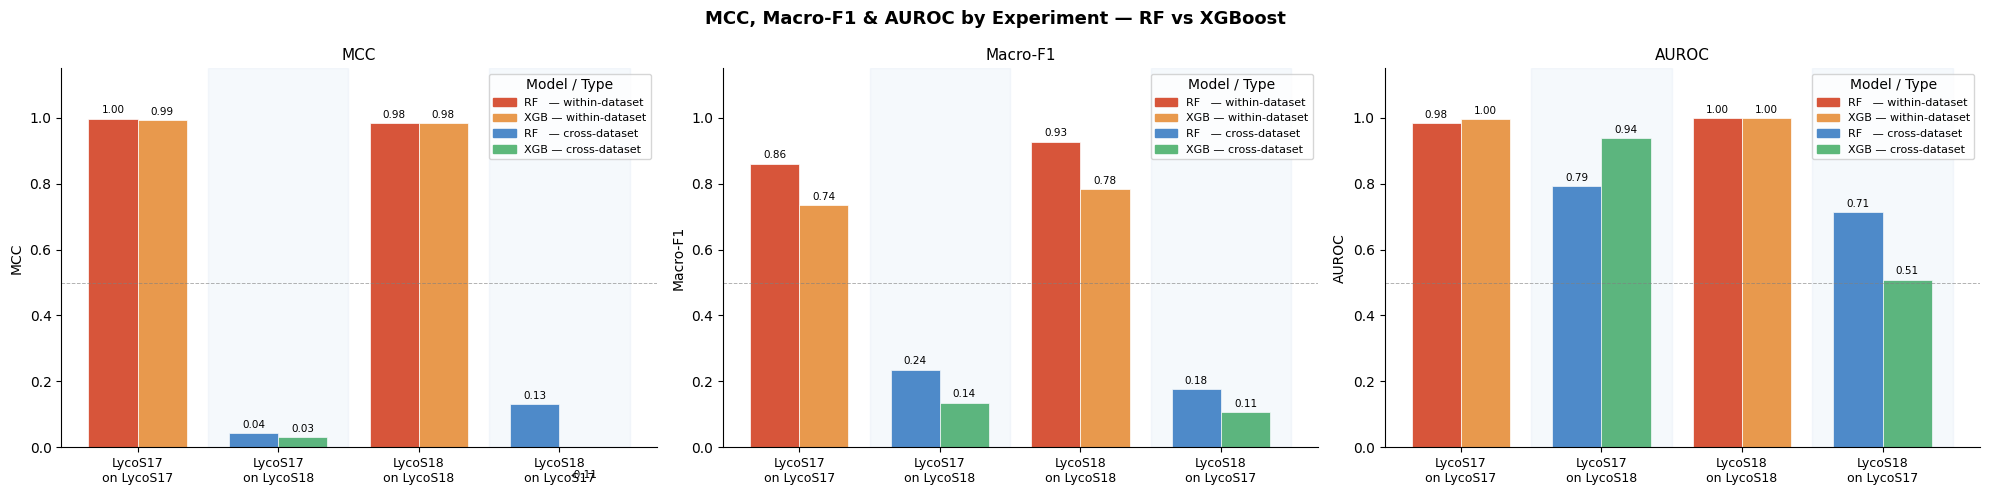

In [12]:
plot_summary_bar_chart(summary)     # utils/viz_utils.py

## 11 · mRMR Feature Selection

Identifies the top features using **minimum Redundancy Maximum Relevance (mRMR)**,
following Cantone et al. (2024) §3.3.3.

mRMR selects features by maximising mutual information with the target label
while minimising redundancy between selected features. Because it is an
incremental method, the optimal subset of *n* features is always the first *n*
entries of the ranked list — matching Table 4 in the paper.

We run mRMR **separately for each training dataset** (LycoS17 and LycoS18)
over the shared feature set, using a capped random sample for computational
feasibility on Colab.

In [13]:
!pip install -q mrmr_selection

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 7.6 MB/s eta 0:00:00


In [14]:
from mrmr import mrmr_classif

# ── Config ────────────────────────────────────────────────────────────────────
MRMR_CAP      = 50_000   # rows sampled for mRMR (mutual-info is expensive)
MRMR_N_FEATS  = 20       # rank this many features (paper uses up to 20)


def run_mrmr(train_df, features, label_col, n_features, cap, name):
    """
    Run mRMR classification on a capped random sample of *train_df*.

    Parameters
    ----------
    train_df   : pd.DataFrame  full training set (will be sampled internally)
    features   : list of str   candidate feature columns
    label_col  : str
    n_features : int           how many top features to return
    cap        : int           max rows used for mutual-info estimation
    name       : str           dataset name for logging

    Returns
    -------
    ranked : list of str  feature names, best first
    """
    sample = (
        train_df[features + [label_col]]
        .sample(n=min(cap, len(train_df)), random_state=RANDOM_STATE)
        .reset_index(drop=True)
    )
    # Drop any columns that are entirely NaN in the sample
    sample = sample.dropna(axis=1, how='all')
    valid_features = [f for f in features if f in sample.columns]

    X_sample = sample[valid_features]
    y_sample = sample[label_col]

    print(f'  [{name}] Running mRMR on {len(sample):,} rows, '
          f'{len(valid_features)} features -> top {n_features} ...')

    ranked = mrmr_classif(
        X         = X_sample,
        y         = y_sample,
        K         = n_features,
        show_progress = False,
    )
    return ranked


print('Running mRMR for LycoS17 ...')
mrmr_17 = run_mrmr(lycos17_train, SHARED_FEATURES, LABEL_COL,
                   MRMR_N_FEATS, MRMR_CAP, 'LycoS17')

print('\nRunning mRMR for LycoS18 ...')
mrmr_18 = run_mrmr(lycos18_train, SHARED_FEATURES, LABEL_COL,
                   MRMR_N_FEATS, MRMR_CAP, 'LycoS18')

print('\n── mRMR top features ─────────────────────────────────────────')
mrmr_df = pd.DataFrame({
    'Rank'   : range(1, MRMR_N_FEATS + 1),
    'LycoS17': mrmr_17,
    'LycoS18': mrmr_18,
})
print(mrmr_df.to_string(index=False))

Running mRMR for LycoS17 ...
  [LycoS17] Running mRMR on 50,000 rows, 76 features -> top 20 ...

Running mRMR for LycoS18 ...
  [LycoS18] Running mRMR on 50,000 rows, 76 features -> top 20 ...

── mRMR top features ─────────────────────────────────────────
 Rank                LycoS17                LycoS18
    1           pkt_len_mean fwd_tcp_init_win_bytes
    2               flag_rst      fwd_bulk_pkt_mean
    3       bwd_pkt_len_mean              pkt_per_s
    4             active_min  fwd_non_empty_pkt_cnt
    5            pkt_len_std            fwd_iat_min
    6        bwd_pkt_len_max    bwd_pkt_hdr_len_min
    7            pkt_len_max   fwd_subflow_pkt_mean
    8        bwd_pkt_len_std          bwd_pkt_per_s
    9    fwd_pkt_hdr_len_min            fwd_pkt_cnt
   10          down_up_ratio    fwd_pkt_hdr_len_tot
   11            pkt_len_var    fwd_pkt_hdr_len_min
   12     bwd_bulk_rate_mean               flag_cwr
   13            active_mean          fwd_pkt_per_s
   14          

### 11.1 · Top-2 features per attack class

The paper runs mRMR **per attack class** (benign + one attack at a time) to find
the two most discriminative features for each attack, then uses those two features
for the KDE / PCA visualisations (Tables 5–7 in Cantone et al.).

We replicate this here for all shared classes.

In [15]:
# ── Per-attack top-2 mRMR (binary: benign vs one attack at a time) ────────────
MRMR_PER_ATTACK_CAP = 20_000   # smaller cap — one run per attack per dataset
BENIGN_LABEL        = 'benign'


def top2_per_attack(train_df, features, label_col, attacks, cap, name):
    """
    For each attack in *attacks*, run binary mRMR (benign vs attack)
    and return the top-2 features.

    Returns
    -------
    dict  {attack_label: [feat1, feat2]}
    """
    results = {}
    for attack in attacks:
        subset = train_df[train_df[label_col].isin([BENIGN_LABEL, attack])].copy()
        if len(subset) < 20:
            print(f'  [{name}] Skipping {attack!r} — too few samples ({len(subset)})')
            results[attack] = [None, None]
            continue

        # Undersample benign to 10:1 ratio (paper §3.3.2)
        n_attack = (subset[label_col] == attack).sum()
        n_benign_cap = min((subset[label_col] == BENIGN_LABEL).sum(), n_attack * 10)
        benign_idx  = subset[subset[label_col] == BENIGN_LABEL].sample(
            n=n_benign_cap, random_state=RANDOM_STATE).index
        attack_idx  = subset[subset[label_col] == attack].index
        subset = subset.loc[benign_idx.union(attack_idx)]

        sample = subset.sample(n=min(cap, len(subset)),
                               random_state=RANDOM_STATE).reset_index(drop=True)
        sample = sample.dropna(axis=1, how='all')
        valid  = [f for f in features if f in sample.columns]

        try:
            ranked = mrmr_classif(
                X=sample[valid],
                y=sample[label_col],
                K=2,
                show_progress=False,
            )
            results[attack] = ranked
        except Exception as e:
            print(f'  [{name}] mRMR failed for {attack!r}: {e}')
            results[attack] = [None, None]

    return results


# Run only on shared attack classes (exclude benign)
ATTACK_CLASSES = [c for c in SHARED_CLASSES if c != BENIGN_LABEL]

print('Per-attack top-2 mRMR — LycoS17 ...')
top2_17 = top2_per_attack(lycos17_train, SHARED_FEATURES, LABEL_COL,
                          ATTACK_CLASSES, MRMR_PER_ATTACK_CAP, 'LycoS17')

print('\nPer-attack top-2 mRMR — LycoS18 ...')
top2_18 = top2_per_attack(lycos18_train, SHARED_FEATURES, LABEL_COL,
                          ATTACK_CLASSES, MRMR_PER_ATTACK_CAP, 'LycoS18')

# Display as a combined table (mirrors Table 5 in Cantone et al.)
rows = []
for attack in ATTACK_CLASSES:
    f17 = top2_17.get(attack, [None, None])
    f18 = top2_18.get(attack, [None, None])
    rows.append({
        'Attack'        : attack,
        'LycoS17 feat1' : f17[0] if len(f17) > 0 else None,
        'LycoS17 feat2' : f17[1] if len(f17) > 1 else None,
        'LycoS18 feat1' : f18[0] if len(f18) > 0 else None,
        'LycoS18 feat2' : f18[1] if len(f18) > 1 else None,
    })

top2_table = pd.DataFrame(rows)
print('\n── Per-attack top-2 features (mirrors Table 5 in Cantone et al.) ──')
print(top2_table.to_string(index=False))

Per-attack top-2 mRMR — LycoS17 ...

Per-attack top-2 mRMR — LycoS18 ...

── Per-attack top-2 features (mirrors Table 5 in Cantone et al.) ──
                  Attack       LycoS17 feat1         LycoS17 feat2          LycoS18 feat1          LycoS18 feat2
                     bot            flag_fin               iat_max               flag_fin           fwd_iat_mean
           dos_goldeneye     bwd_pkt_len_std fwd_non_empty_pkt_cnt    fwd_pkt_hdr_len_min fwd_tcp_init_win_bytes
                dos_hulk        pkt_len_mean      bwd_pkt_len_mean fwd_tcp_init_win_bytes    fwd_pkt_hdr_len_min
        dos_slowhttptest         active_mean           bwd_iat_std              pkt_per_s          bwd_pkt_per_s
           dos_slowloris fwd_pkt_hdr_len_min          bwd_iat_mean           bwd_iat_mean    fwd_pkt_hdr_len_min
             ftp_patator       down_up_ratio           fwd_iat_tot          bwd_pkt_per_s              pkt_per_s
             ssh_patator        fwd_flag_psh         down_up_ratio 

## 12 · PCA Cluster Visualisation per Attack

Following Cantone et al. §3.3.4 and Figure 8: for each attack class we project
LycoS17 and LycoS18 samples into a 2-D PCA subspace **fitted on LycoS17** and
plot both datasets' distributions together.

This reveals whether the two datasets occupy similar or divergent regions of
feature space — the primary explanation for cross-dataset generalisation failure.

Plotting PCA for 9 attack classes ...
Saved: pca_attack_clusters.png


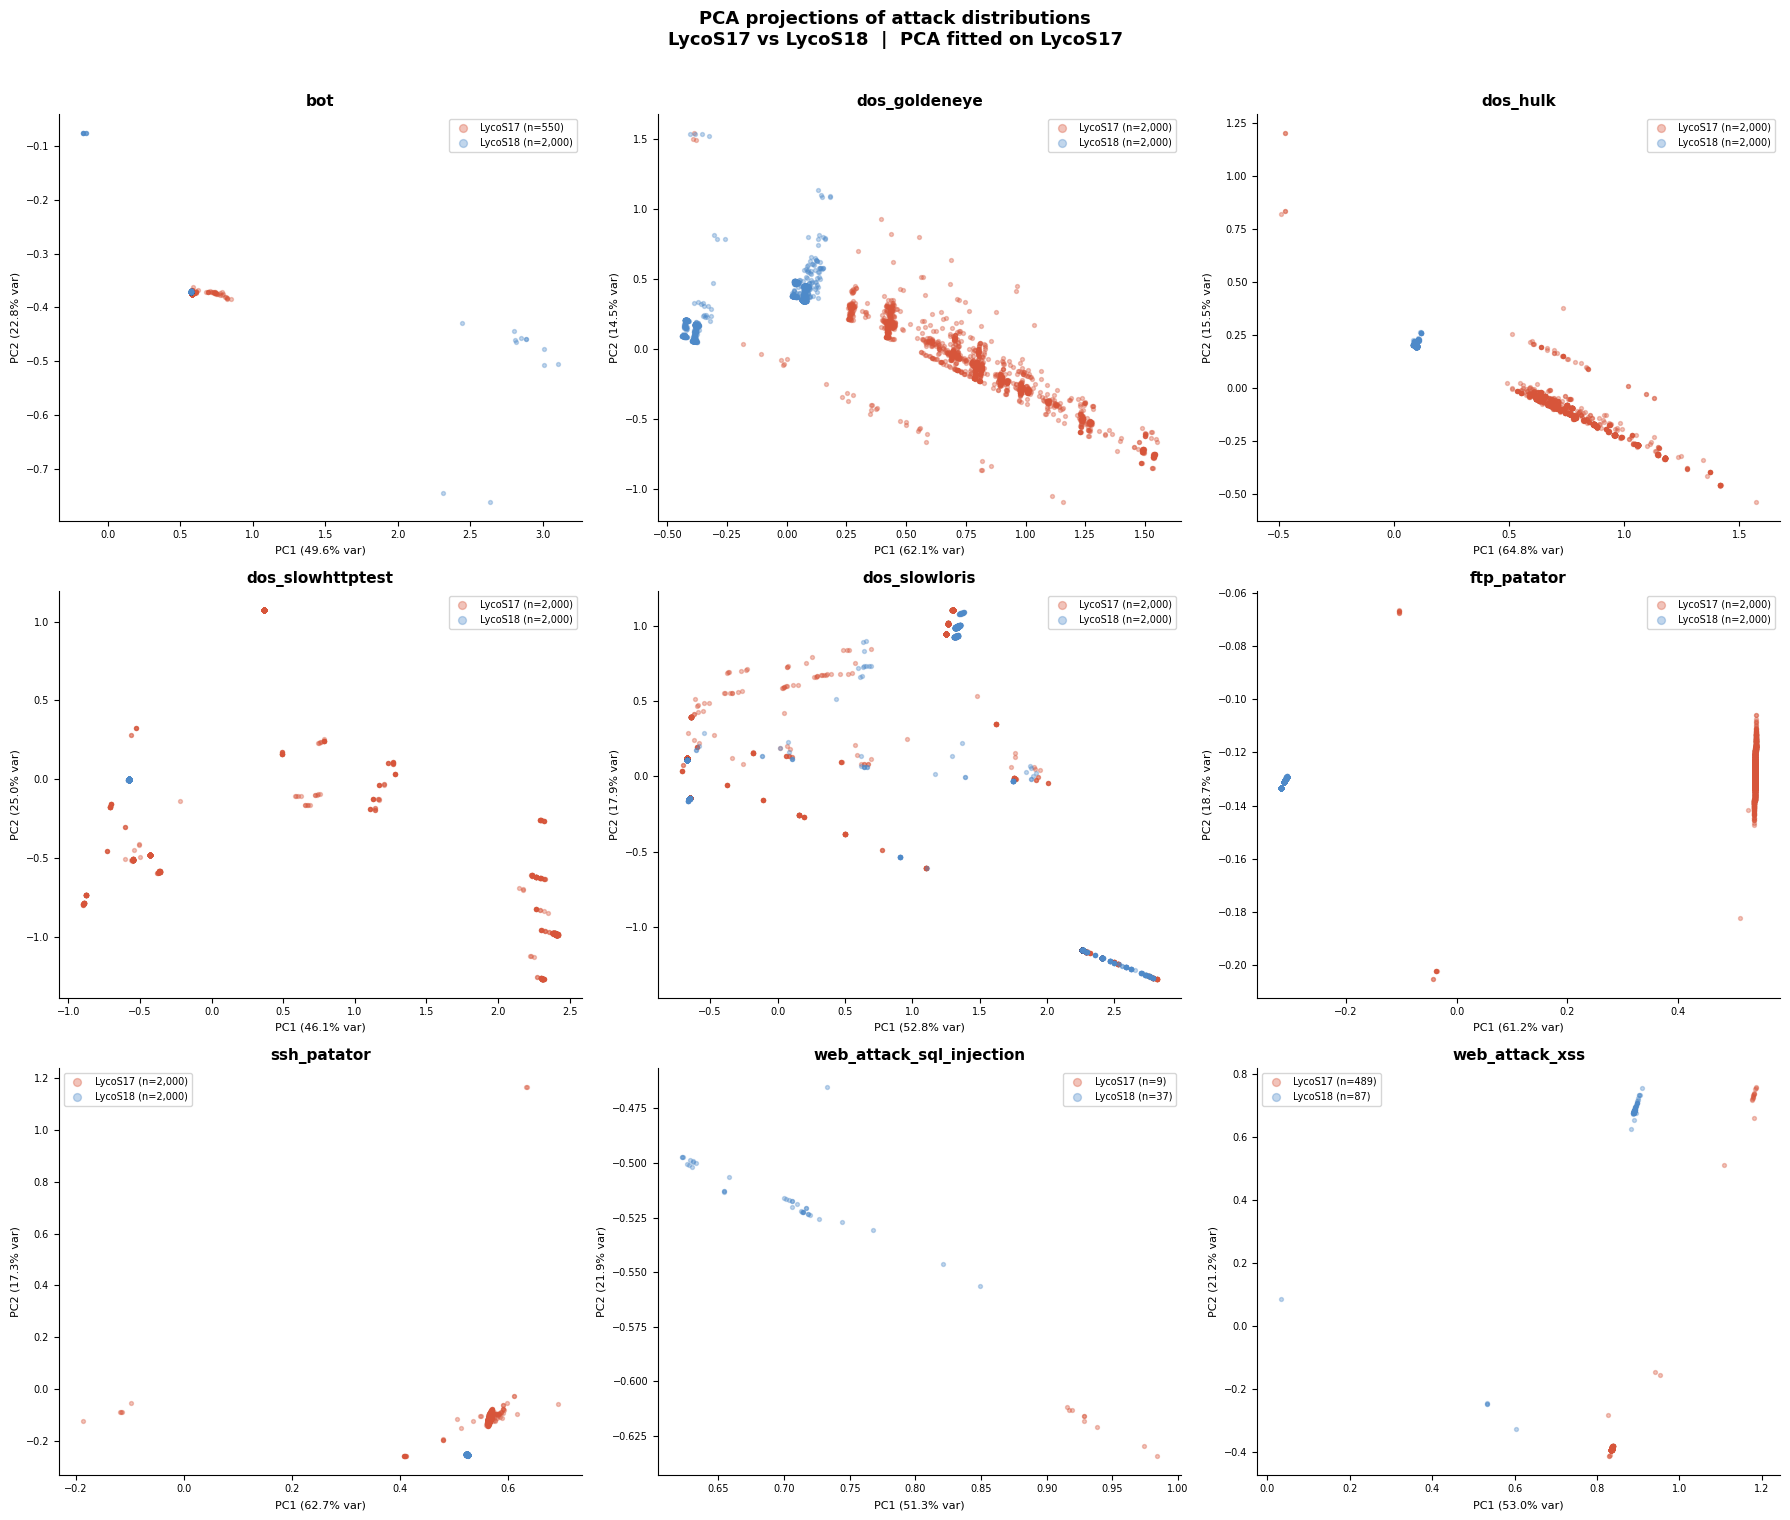

In [16]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler

# ── Config ────────────────────────────────────────────────────────────────────
PCA_SAMPLE_CAP = 2_000   # samples per class per dataset for plotting
PCA_COMPONENTS = 2

COLOUR_17 = '#D7553A'   # red   — LycoS17
COLOUR_18 = '#4E8AC9'   # blue  — LycoS18
ALPHA     = 0.35
MARKER_SZ = 8


def pca_attack_grid(lycos17_train, lycos18_train, features, label_col,
                    attacks, sample_cap, n_components=2):
    """
    For each attack in *attacks*:
      1. Fit MinMaxScaler + PCA on LycoS17 (benign + attack samples).
      2. Project both LycoS17 and LycoS18 attack samples into that subspace.
      3. Scatter-plot both distributions side by side.

    Mirrors Figure 8 of Cantone et al. (2024).
    """
    n_attacks = len(attacks)
    n_cols    = 3
    n_rows    = (n_attacks + n_cols - 1) // n_cols

    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(6 * n_cols, 5 * n_rows),
    )
    axes = np.array(axes).flatten()

    for idx, attack in enumerate(attacks):
        ax = axes[idx]

        # ── Gather samples ────────────────────────────────────────────────────
        def get_attack_samples(df, attack_label, cap):
            sub = df[df[label_col] == attack_label][features].copy()
            sub = sub.dropna()
            if len(sub) > cap:
                sub = sub.sample(n=cap, random_state=RANDOM_STATE)
            return sub.values.astype(np.float64)

        X17 = get_attack_samples(lycos17_train, attack, sample_cap)
        X18 = get_attack_samples(lycos18_train, attack, sample_cap)

        if len(X17) == 0 and len(X18) == 0:
            ax.set_visible(False)
            continue

        # ── Fit scaler + PCA on LycoS17 ───────────────────────────────────────
        # Also include benign samples from LycoS17 so PCA captures the full
        # variance of the training distribution (matches paper methodology).
        benign17 = (
            lycos17_train[lycos17_train[label_col] == BENIGN_LABEL][features]
            .dropna()
            .sample(n=min(sample_cap, len(
                lycos17_train[lycos17_train[label_col] == BENIGN_LABEL])),
                random_state=RANDOM_STATE)
            .values.astype(np.float64)
        )
        X17_fit = np.vstack([benign17, X17]) if len(X17) > 0 else benign17

        scaler = MinMaxScaler()
        X17_fit_scaled = scaler.fit_transform(X17_fit)

        pca = PCA(n_components=n_components, random_state=RANDOM_STATE)
        pca.fit(X17_fit_scaled)

        # ── Project attack samples only ────────────────────────────────────────
        def project(X):
            if len(X) == 0:
                return np.empty((0, n_components))
            return pca.transform(scaler.transform(X))

        P17 = project(X17)
        P18 = project(X18)

        var_explained = pca.explained_variance_ratio_

        # ── Plot ──────────────────────────────────────────────────────────────
        if len(P17) > 0:
            ax.scatter(P17[:, 0], P17[:, 1],
                       c=COLOUR_17, alpha=ALPHA, s=MARKER_SZ,
                       label=f'LycoS17 (n={len(P17):,})')
        if len(P18) > 0:
            ax.scatter(P18[:, 0], P18[:, 1],
                       c=COLOUR_18, alpha=ALPHA, s=MARKER_SZ,
                       label=f'LycoS18 (n={len(P18):,})')

        ax.set_title(attack, fontsize=11, fontweight='bold')
        ax.set_xlabel(
            f'PC1 ({var_explained[0]*100:.1f}% var)', fontsize=8)
        ax.set_ylabel(
            f'PC2 ({var_explained[1]*100:.1f}% var)', fontsize=8)
        ax.tick_params(labelsize=7)
        ax.spines[['top', 'right']].set_visible(False)
        ax.legend(fontsize=7, markerscale=2)

    # Hide any unused subplot panels
    for idx in range(len(attacks), len(axes)):
        axes[idx].set_visible(False)

    fig.suptitle(
        'PCA projections of attack distributions\n'
        'LycoS17 vs LycoS18  |  PCA fitted on LycoS17',
        fontsize=13, fontweight='bold', y=1.01
    )
    plt.tight_layout()
    plt.savefig('pca_attack_clusters.png', dpi=150, bbox_inches='tight')
    print('Saved: pca_attack_clusters.png')
    plt.show()


print(f'Plotting PCA for {len(ATTACK_CLASSES)} attack classes ...')
pca_attack_grid(
    lycos17_train = lycos17_train,
    lycos18_train = lycos18_train,
    features      = SHARED_FEATURES,
    label_col     = LABEL_COL,
    attacks       = ATTACK_CLASSES,
    sample_cap    = PCA_SAMPLE_CAP,
)

### 12.1 · PCA using top-2 mRMR features only

In addition to the full-feature PCA, the paper also visualises distributions
in the **2-D subspace of the top-2 mRMR features** per attack (Figure 7).
This gives an attack-specific view where the axes have direct semantic meaning
(they are actual feature values, not linear combinations).

Plotting top-2 mRMR scatter (LycoS17 ranking) ...
Saved: top2_mrmr_scatter_LycoS17.png


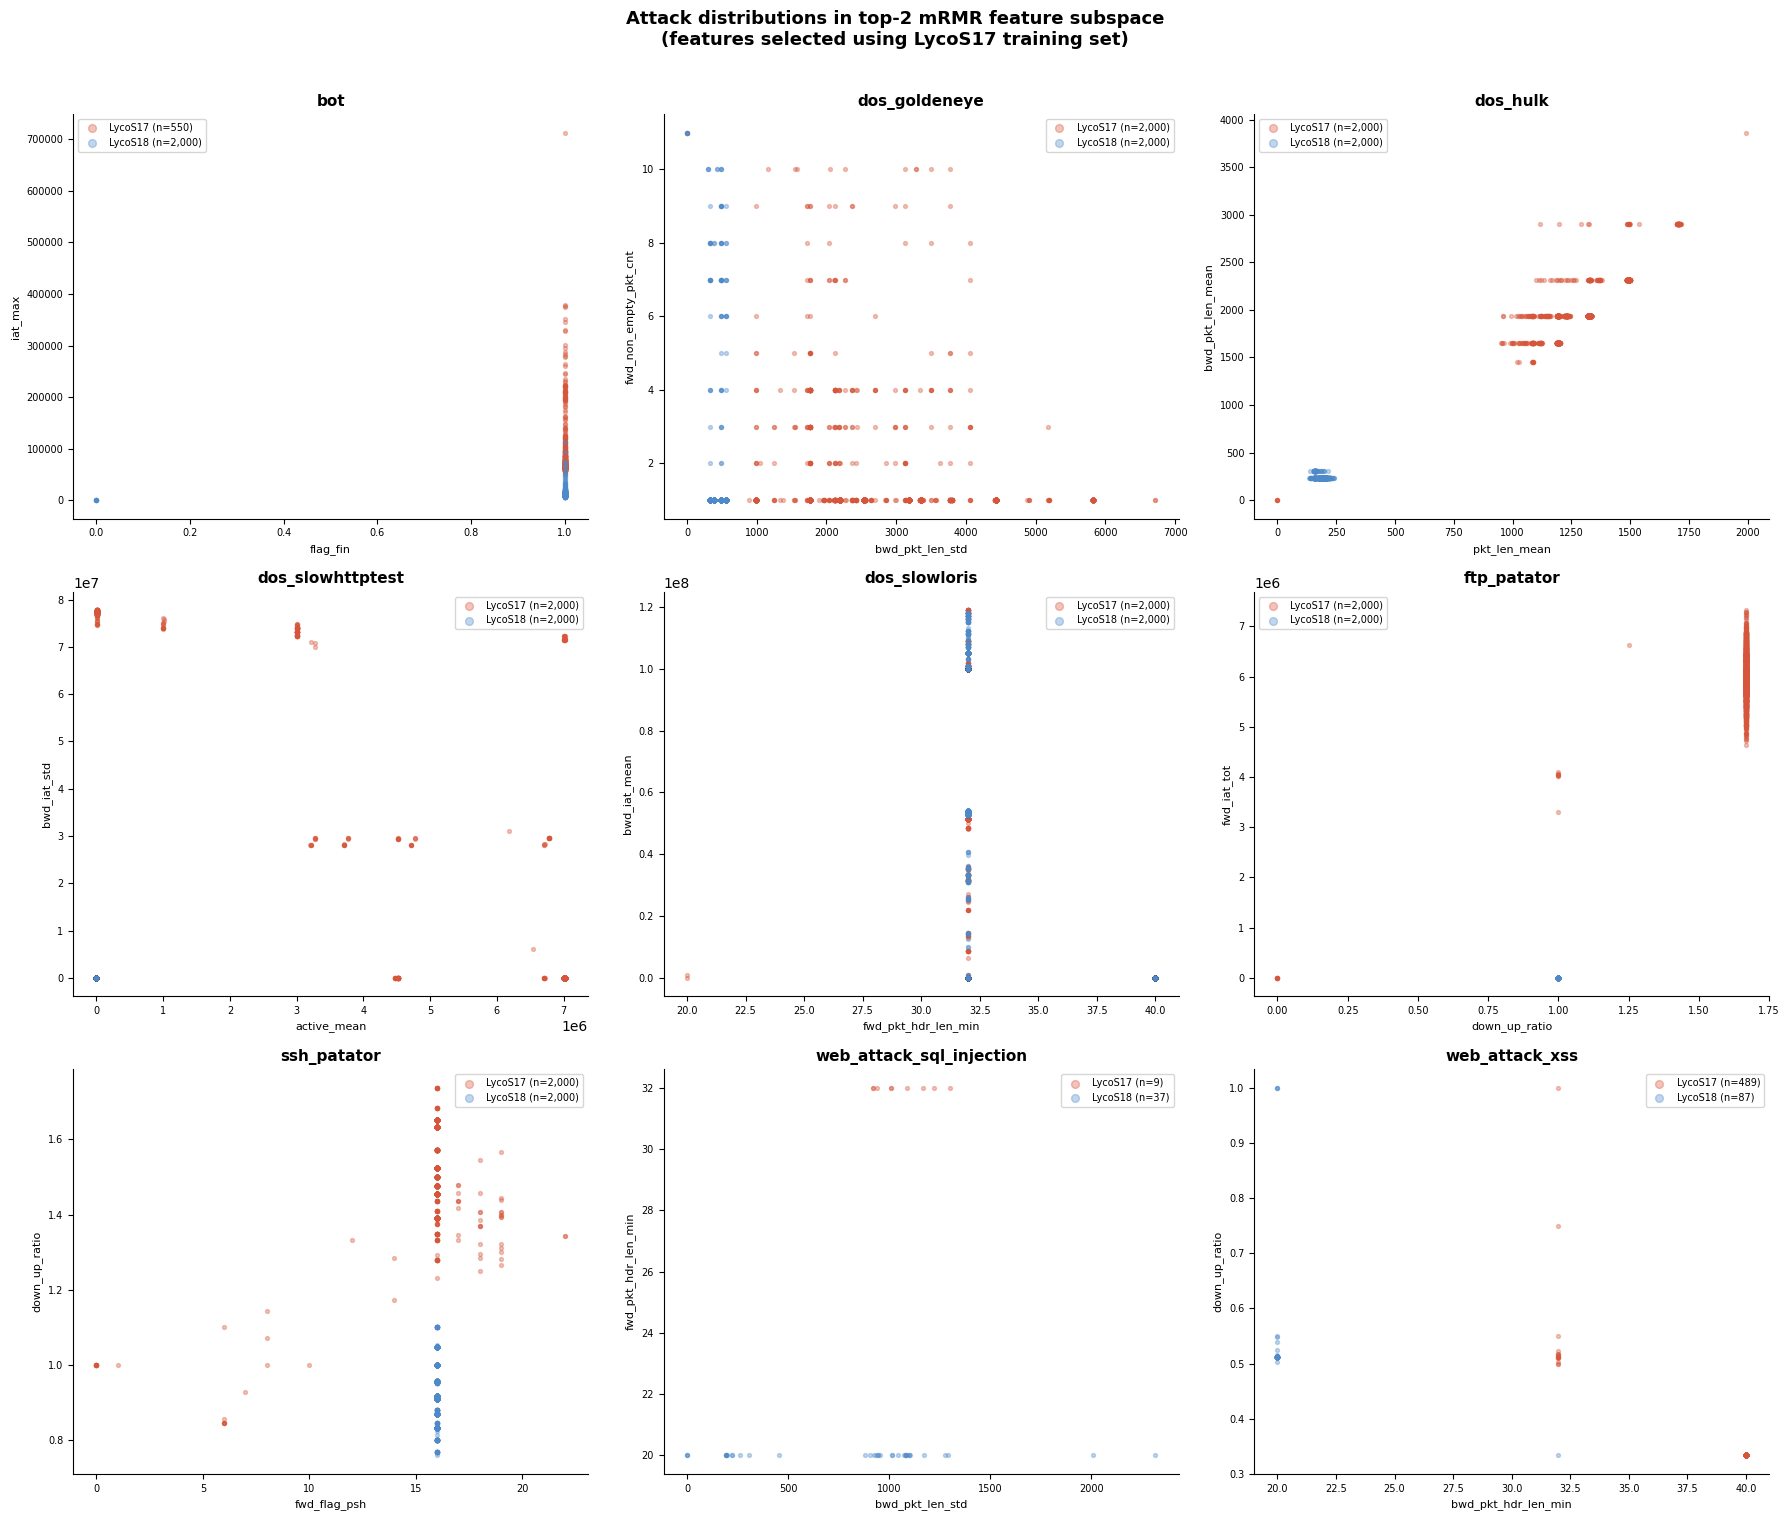


Plotting top-2 mRMR scatter (LycoS18 ranking) ...
Saved: top2_mrmr_scatter_LycoS18.png


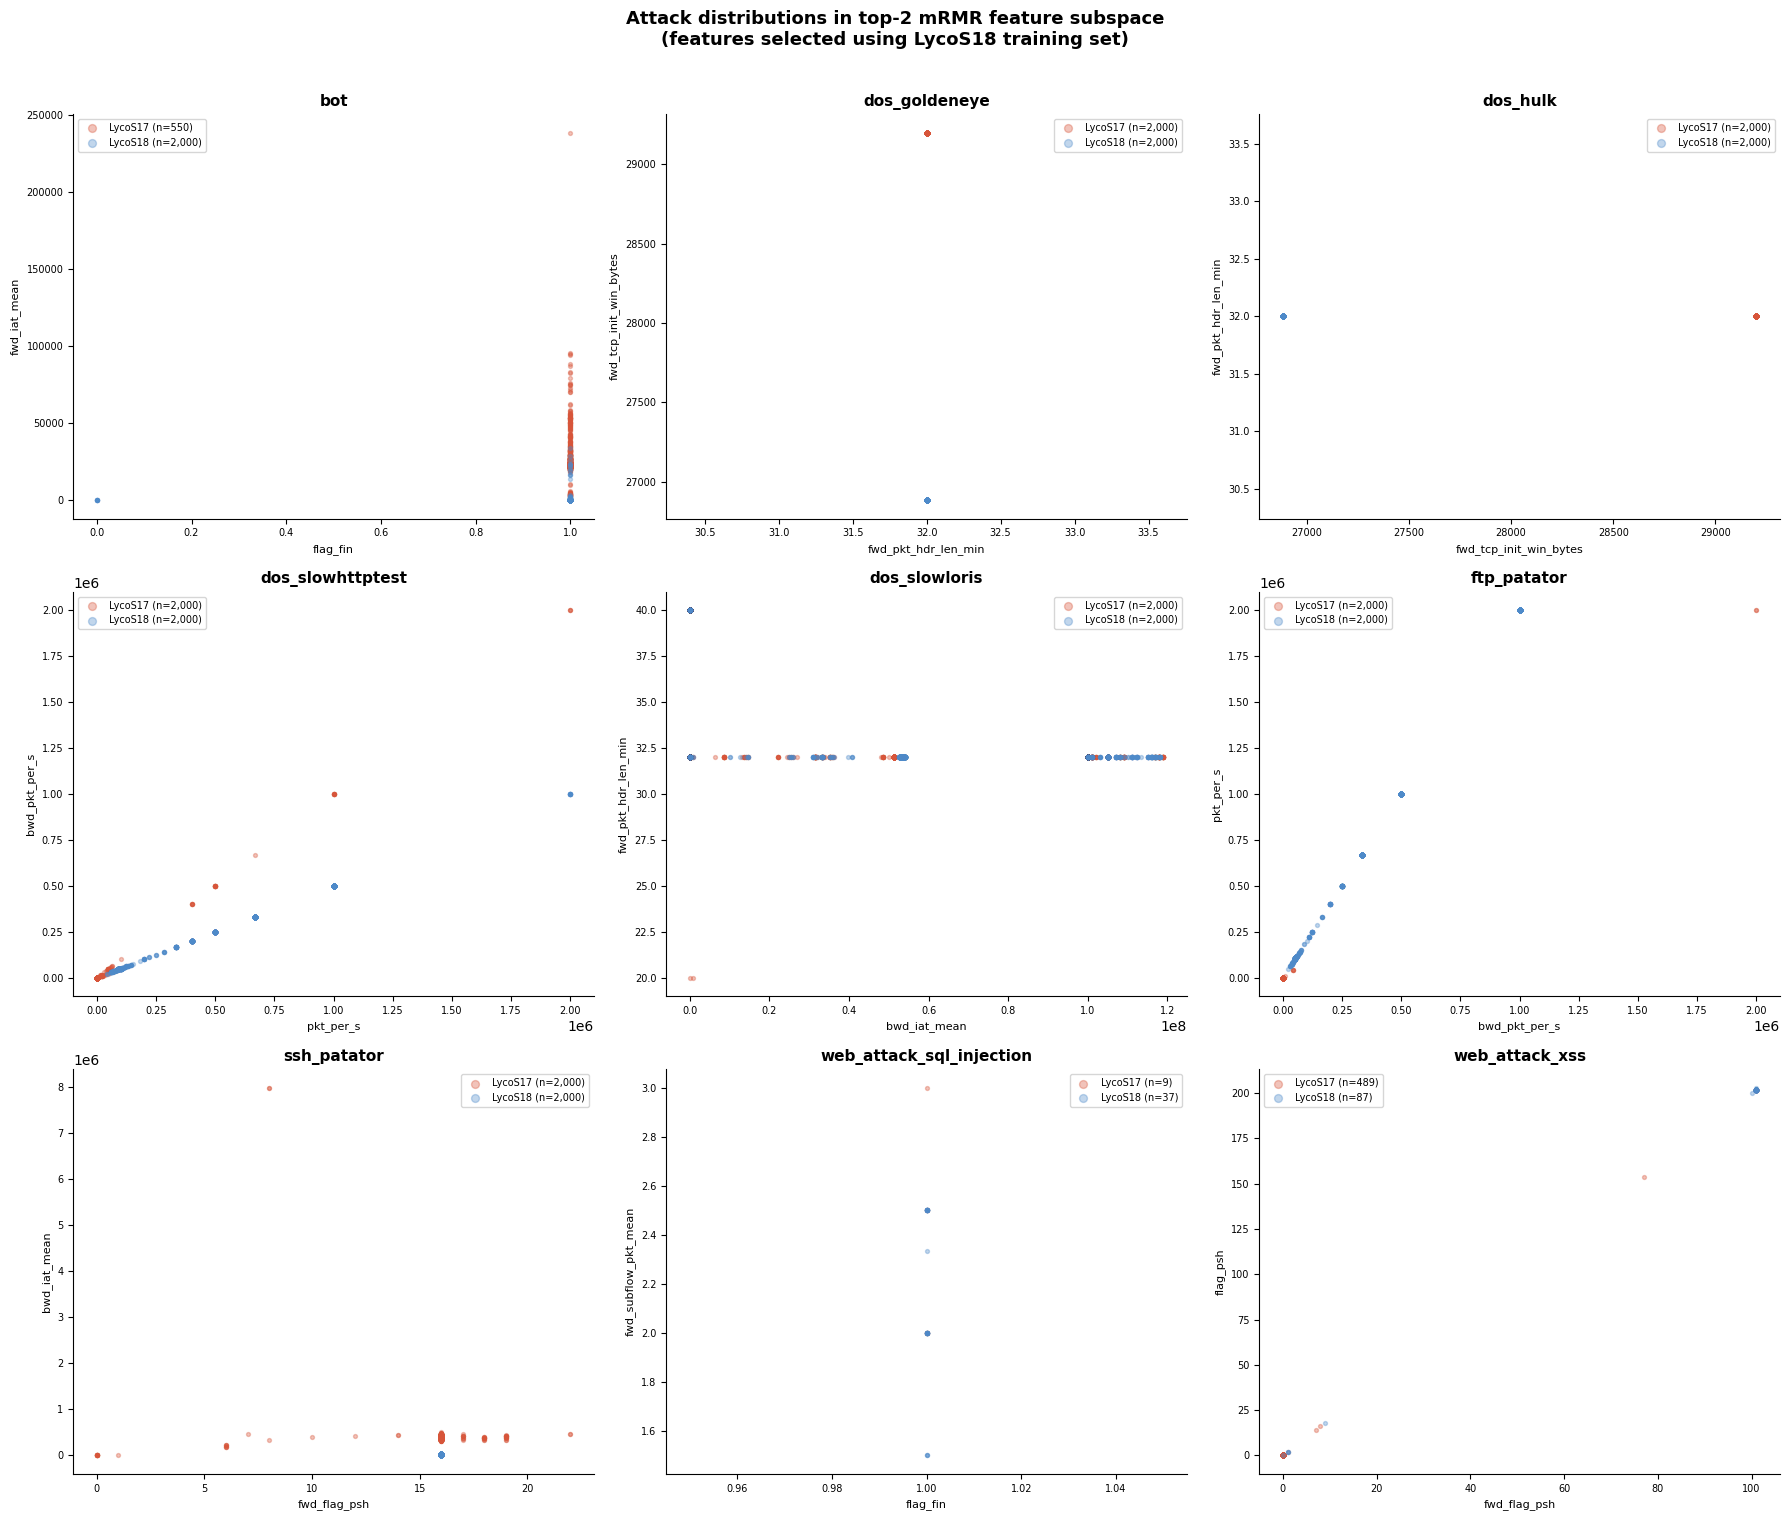

In [17]:
def top2_feature_scatter_grid(lycos17_train, lycos18_train, top2_lookup,
                               label_col, attacks, sample_cap, dataset_name='LycoS17'):
    """
    Scatter plots in the top-2 mRMR feature subspace for each attack.
    *top2_lookup* : dict {attack: [feat1, feat2]} from run_mrmr per attack.
    *dataset_name*: which dataset's mRMR ranking to use for the axes.

    Mirrors Figure 7 of Cantone et al. (2024).
    """
    n_cols  = 3
    n_rows  = (len(attacks) + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=(6 * n_cols, 5 * n_rows))
    axes = np.array(axes).flatten()

    for idx, attack in enumerate(attacks):
        ax     = axes[idx]
        feats  = top2_lookup.get(attack, [None, None])
        feat1, feat2 = feats[0], feats[1] if len(feats) > 1 else None

        if feat1 is None or feat2 is None:
            ax.text(0.5, 0.5, 'No features\navailable',
                    ha='center', va='center', transform=ax.transAxes, fontsize=9)
            ax.set_title(attack, fontsize=10, fontweight='bold')
            ax.set_visible(True)
            continue

        def get_vals(df, attack_label, f1, f2, cap):
            sub = df[df[label_col] == attack_label][[f1, f2]].dropna()
            if len(sub) > cap:
                sub = sub.sample(n=cap, random_state=RANDOM_STATE)
            return sub[f1].values, sub[f2].values

        x17, y17 = get_vals(lycos17_train, attack, feat1, feat2, sample_cap)
        x18, y18 = get_vals(lycos18_train, attack, feat1, feat2, sample_cap)

        if len(x17) > 0:
            ax.scatter(x17, y17, c=COLOUR_17, alpha=ALPHA, s=MARKER_SZ,
                       label=f'LycoS17 (n={len(x17):,})')
        if len(x18) > 0:
            ax.scatter(x18, y18, c=COLOUR_18, alpha=ALPHA, s=MARKER_SZ,
                       label=f'LycoS18 (n={len(x18):,})')

        ax.set_title(attack, fontsize=11, fontweight='bold')
        ax.set_xlabel(feat1, fontsize=8)
        ax.set_ylabel(feat2, fontsize=8)
        ax.tick_params(labelsize=7)
        ax.spines[['top', 'right']].set_visible(False)
        ax.legend(fontsize=7, markerscale=2)

    for idx in range(len(attacks), len(axes)):
        axes[idx].set_visible(False)

    fig.suptitle(
        f'Attack distributions in top-2 mRMR feature subspace\n'
        f'(features selected using {dataset_name} training set)',
        fontsize=13, fontweight='bold', y=1.01
    )
    plt.tight_layout()
    fname = f'top2_mrmr_scatter_{dataset_name}.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    print(f'Saved: {fname}')
    plt.show()


# Plot using LycoS17 mRMR feature ranking
print('Plotting top-2 mRMR scatter (LycoS17 ranking) ...')
top2_feature_scatter_grid(
    lycos17_train = lycos17_train,
    lycos18_train = lycos18_train,
    top2_lookup   = top2_17,
    label_col     = LABEL_COL,
    attacks       = ATTACK_CLASSES,
    sample_cap    = PCA_SAMPLE_CAP,
    dataset_name  = 'LycoS17',
)

# Plot using LycoS18 mRMR feature ranking
print('\nPlotting top-2 mRMR scatter (LycoS18 ranking) ...')
top2_feature_scatter_grid(
    lycos17_train = lycos17_train,
    lycos18_train = lycos18_train,
    top2_lookup   = top2_18,
    label_col     = LABEL_COL,
    attacks       = ATTACK_CLASSES,
    sample_cap    = PCA_SAMPLE_CAP,
    dataset_name  = 'LycoS18',
)

## 13 · RF & XGBoost with mRMR Features + Benign Undersampling

Re-runs the four experiments from §8 with two changes that follow the paper more closely:

1. **mRMR feature subset** — uses the top-N features identified in §11 (ranked by the *training* dataset) rather than the full shared feature set.
2. **Benign undersampling** — caps the benign class at a 10:1 ratio relative to total attack traffic before training, following Cantone et al. §3.3.2. This forces the model to learn attack patterns rather than defaulting to the dominant benign class.

For cross-dataset experiments (2 and 4) the feature list used is the one ranked by the **training** dataset's mRMR run, since mRMR is fitted on training data only.

Results are compared against the all-features runs from §9 to quantify the effect of each change.

In [18]:
# ── How many top mRMR features to use ────────────────────────────────────────
# Paper tests 1,2,3,4,5,10,20. We default to 10
# Change this to experiment with different subset sizes.
TOP_N_FEATURES = 10

# ── Benign undersampling ratio ────────────────────────────────────────────────
# Paper §3.3.2: undersample benign to maintain a 10:1 ratio
# (benign : total attack) to trade off class imbalance.
# Note: Undersampling technically not needed since the splits already made to account for balance between the attack and benign classes
# Ratio usually between 1.0 t0 2.5 benign to attack
BENIGN_RATIO = 10

# Derive per-dataset top-N feature lists from the mRMR runs in §11.
# mrmr_17 and mrmr_18 are the ranked lists produced there.
TOP_FEATURES_17 = mrmr_17[:TOP_N_FEATURES]
TOP_FEATURES_18 = mrmr_18[:TOP_N_FEATURES]

print(f'Using top {TOP_N_FEATURES} mRMR features')
print(f'  LycoS17: {TOP_FEATURES_17}')
print(f'  LycoS18: {TOP_FEATURES_18}')
print(f'Benign undersampling ratio: {BENIGN_RATIO}:1')

Using top 10 mRMR features
  LycoS17: ['pkt_len_mean', 'flag_rst', 'bwd_pkt_len_mean', 'active_min', 'pkt_len_std', 'bwd_pkt_len_max', 'pkt_len_max', 'bwd_pkt_len_std', 'fwd_pkt_hdr_len_min', 'down_up_ratio']
  LycoS18: ['fwd_tcp_init_win_bytes', 'fwd_bulk_pkt_mean', 'pkt_per_s', 'fwd_non_empty_pkt_cnt', 'fwd_iat_min', 'bwd_pkt_hdr_len_min', 'fwd_subflow_pkt_mean', 'bwd_pkt_per_s', 'fwd_pkt_cnt', 'fwd_pkt_hdr_len_tot']
Benign undersampling ratio: 10:1


### 13.2 · Undersampling helper

In [19]:
def undersample_benign(df, label_col, benign_label, ratio, random_state):
    """
    Undersample the benign class so that
        n_benign <= ratio * n_total_attack

    All attack rows are kept; only the benign class is reduced.
    If the existing benign count is already within the ratio, the
    DataFrame is returned unchanged.

    Parameters
    ----------
    df           : pd.DataFrame
    label_col    : str
    benign_label : str   label string for the benign class
    ratio        : int   target benign-to-attack ratio (e.g. 10)
    random_state : int

    Returns
    -------
    pd.DataFrame  with benign rows reduced, shuffled
    """
    attack_df = df[df[label_col] != benign_label]
    benign_df = df[df[label_col] == benign_label]

    n_attack     = len(attack_df)
    n_benign_cap = n_attack * ratio

    if len(benign_df) > n_benign_cap:
        benign_df = benign_df.sample(
            n=n_benign_cap, random_state=random_state
        )

    result = pd.concat([benign_df, attack_df], ignore_index=True)
    return result.sample(frac=1, random_state=random_state).reset_index(drop=True)

print('Undersampling helper defined.')

Undersampling helper defined.


### 13.3 · Preprocessing helper (mRMR feature subset)

In [20]:
def prepare_Xy_mrmr(
    train_df,
    test_df,
    features,
    label_col,
    shared_classes=None,
    benign_label=BENIGN_LABEL,
    benign_ratio=BENIGN_RATIO,
    random_state=RANDOM_STATE,
):
    """
    Identical to prepare_Xy from data_utils, but also:
      - applies benign undersampling (10:1) to the training set
      - accepts an arbitrary feature list (the mRMR top-N subset)

    The test set is never undersampled — evaluation must reflect the
    true class distribution.

    Returns
    -------
    X_train, X_test  : np.ndarray (MinMax scaled)
    y_train, y_test  : np.ndarray (integer encoded)
    le               : fitted LabelEncoder
    """
    from sklearn.preprocessing import MinMaxScaler, LabelEncoder

    # Filter to shared classes if requested
    if shared_classes is not None:
        train_df = train_df[train_df[label_col].isin(shared_classes)].copy()
        test_df  = test_df[test_df[label_col].isin(shared_classes)].copy()

    # Undersample benign on training set only
    before = len(train_df)
    train_df = undersample_benign(
        train_df, label_col, benign_label, benign_ratio, random_state
    )
    after = len(train_df)
    n_benign_after = (train_df[label_col] == benign_label).sum()
    n_attack_after = after - n_benign_after
    print(f'  Undersampling: {before:,} -> {after:,} rows '
          f'(benign={n_benign_after:,}, attack={n_attack_after:,}, '
          f'ratio={n_benign_after/max(n_attack_after,1):.1f}:1)')

    # Ensure all requested features exist in both DataFrames
    valid_features = [
        f for f in features
        if f in train_df.columns and f in test_df.columns
    ]
    if len(valid_features) < len(features):
        missing = set(features) - set(valid_features)
        print(f'  Warning: {len(missing)} features not found and skipped: {missing}')

    X_train_raw = train_df[valid_features].values.astype(np.float64)
    X_test_raw  = test_df[valid_features].values.astype(np.float64)

    scaler  = MinMaxScaler()
    X_train = scaler.fit_transform(X_train_raw)
    X_test  = scaler.transform(X_test_raw)

    le      = LabelEncoder()
    y_train = le.fit_transform(train_df[label_col].values)
    y_test  = np.array([
        le.transform([lbl])[0] if lbl in le.classes_ else -1
        for lbl in test_df[label_col].values
    ])

    print(f'  Train: {X_train.shape[0]:,} rows | Test: {X_test.shape[0]:,} rows')
    print(f'  Features ({len(valid_features)}): {valid_features}')
    print(f'  Classes ({len(le.classes_)}): {list(le.classes_)}')
    return X_train, X_test, y_train, y_test, le


print('Preprocessing helper defined.')

Preprocessing helper defined.


### 13.4 · Define experiments

Same four train/test combinations as §7, but each experiment now also carries
the mRMR feature list ranked by its **training** dataset.

In [21]:
EXPERIMENTS_MRMR = [
    {
        'id'            : 1,
        'label'         : 'Train LycoS17 -> Eval LycoS17 (within-dataset)',
        'train_df'      : lycos17_train,
        'test_df'       : lycos17_test,
        'shared_classes': None,
        # Use LycoS17 mRMR ranking — training dataset is LycoS17
        'features'      : TOP_FEATURES_17,
    },
    {
        'id'            : 2,
        'label'         : 'Train LycoS17 -> Eval LycoS18 (cross-dataset)',
        'train_df'      : lycos17_train,
        'test_df'       : lycos18_test,
        'shared_classes': SHARED_CLASSES,
        # Training on LycoS17, so use LycoS17 mRMR ranking
        'features'      : TOP_FEATURES_17,
    },
    {
        'id'            : 3,
        'label'         : 'Train LycoS18 -> Eval LycoS18 (within-dataset)',
        'train_df'      : lycos18_train,
        'test_df'       : lycos18_test,
        'shared_classes': None,
        # Use LycoS18 mRMR ranking — training dataset is LycoS18
        'features'      : TOP_FEATURES_18,
    },
    {
        'id'            : 4,
        'label'         : 'Train LycoS18 -> Eval LycoS17 (cross-dataset)',
        'train_df'      : lycos18_train,
        'test_df'       : lycos17_test,
        'shared_classes': SHARED_CLASSES,
        # Training on LycoS18, so use LycoS18 mRMR ranking
        'features'      : TOP_FEATURES_18,
    },
]

for e in EXPERIMENTS_MRMR:
    tag = 'within' if e['shared_classes'] is None else 'cross'
    print(f"  [{e['id']}] [{tag:6s}] {e['label']}")
    print(f"           features: {e['features']}")

  [1] [within] Train LycoS17 -> Eval LycoS17 (within-dataset)
           features: ['pkt_len_mean', 'flag_rst', 'bwd_pkt_len_mean', 'active_min', 'pkt_len_std', 'bwd_pkt_len_max', 'pkt_len_max', 'bwd_pkt_len_std', 'fwd_pkt_hdr_len_min', 'down_up_ratio']
  [2] [cross ] Train LycoS17 -> Eval LycoS18 (cross-dataset)
           features: ['pkt_len_mean', 'flag_rst', 'bwd_pkt_len_mean', 'active_min', 'pkt_len_std', 'bwd_pkt_len_max', 'pkt_len_max', 'bwd_pkt_len_std', 'fwd_pkt_hdr_len_min', 'down_up_ratio']
  [3] [within] Train LycoS18 -> Eval LycoS18 (within-dataset)
           features: ['fwd_tcp_init_win_bytes', 'fwd_bulk_pkt_mean', 'pkt_per_s', 'fwd_non_empty_pkt_cnt', 'fwd_iat_min', 'bwd_pkt_hdr_len_min', 'fwd_subflow_pkt_mean', 'bwd_pkt_per_s', 'fwd_pkt_cnt', 'fwd_pkt_hdr_len_tot']
  [4] [cross ] Train LycoS18 -> Eval LycoS17 (cross-dataset)
           features: ['fwd_tcp_init_win_bytes', 'fwd_bulk_pkt_mean', 'pkt_per_s', 'fwd_non_empty_pkt_cnt', 'fwd_iat_min', 'bwd_pkt_hdr_len_min', '

In [22]:
# XGB specific adjustments for this experiment run
XGB_PARAM_GRID_MRMR = {
    'max_depth'       : [3, 6, 12],
    'n_estimators'    : [10, 50],
    'learning_rate'   : [0.1, 0.3, 1],
    'booster'         : ['gbtree'],        # remove gblinear
    'min_child_weight': [0.5, 1, 2],
    'gamma'           : [0, 1, 10],
}
GRID_SEARCH_CAP_MRMR = 100_000

### 13.5 · Run experiments

> **Runtime note:** grid search is still capped at `GRID_SEARCH_CAP` rows.
> Undersampling is applied before the cap, so the grid-search subset is
> already class-balanced.


######################################################################
  EXPERIMENT 1 [mRMR + undersampling]: Train LycoS17 -> Eval LycoS17 (within-dataset)
######################################################################

[Preprocessing]
  Undersampling: 660,944 -> 660,944 rows (benign=330,474, attack=330,470, ratio=1.0:1)
  Train: 660,944 rows | Test: 220,312 rows
  Features (10): ['pkt_len_mean', 'flag_rst', 'bwd_pkt_len_mean', 'active_min', 'pkt_len_std', 'bwd_pkt_len_max', 'pkt_len_max', 'bwd_pkt_len_std', 'fwd_pkt_hdr_len_min', 'down_up_ratio']
  Classes (14): ['benign', 'bot', 'ddos', 'dos_goldeneye', 'dos_hulk', 'dos_slowhttptest', 'dos_slowloris', 'ftp_patator', 'heartbleed', 'portscan', 'ssh_patator', 'web_attack_bruteforce', 'web_attack_sql_injection', 'web_attack_xss']

[Random Forest - grid search]
  Grid search on 100,000 / 660,944 rows (capped)
  Best params : {'criterion': 'entropy', 'max_depth': None, 'max_features': 'sqrt', 'min_samples_split': 4, 'n_estimators

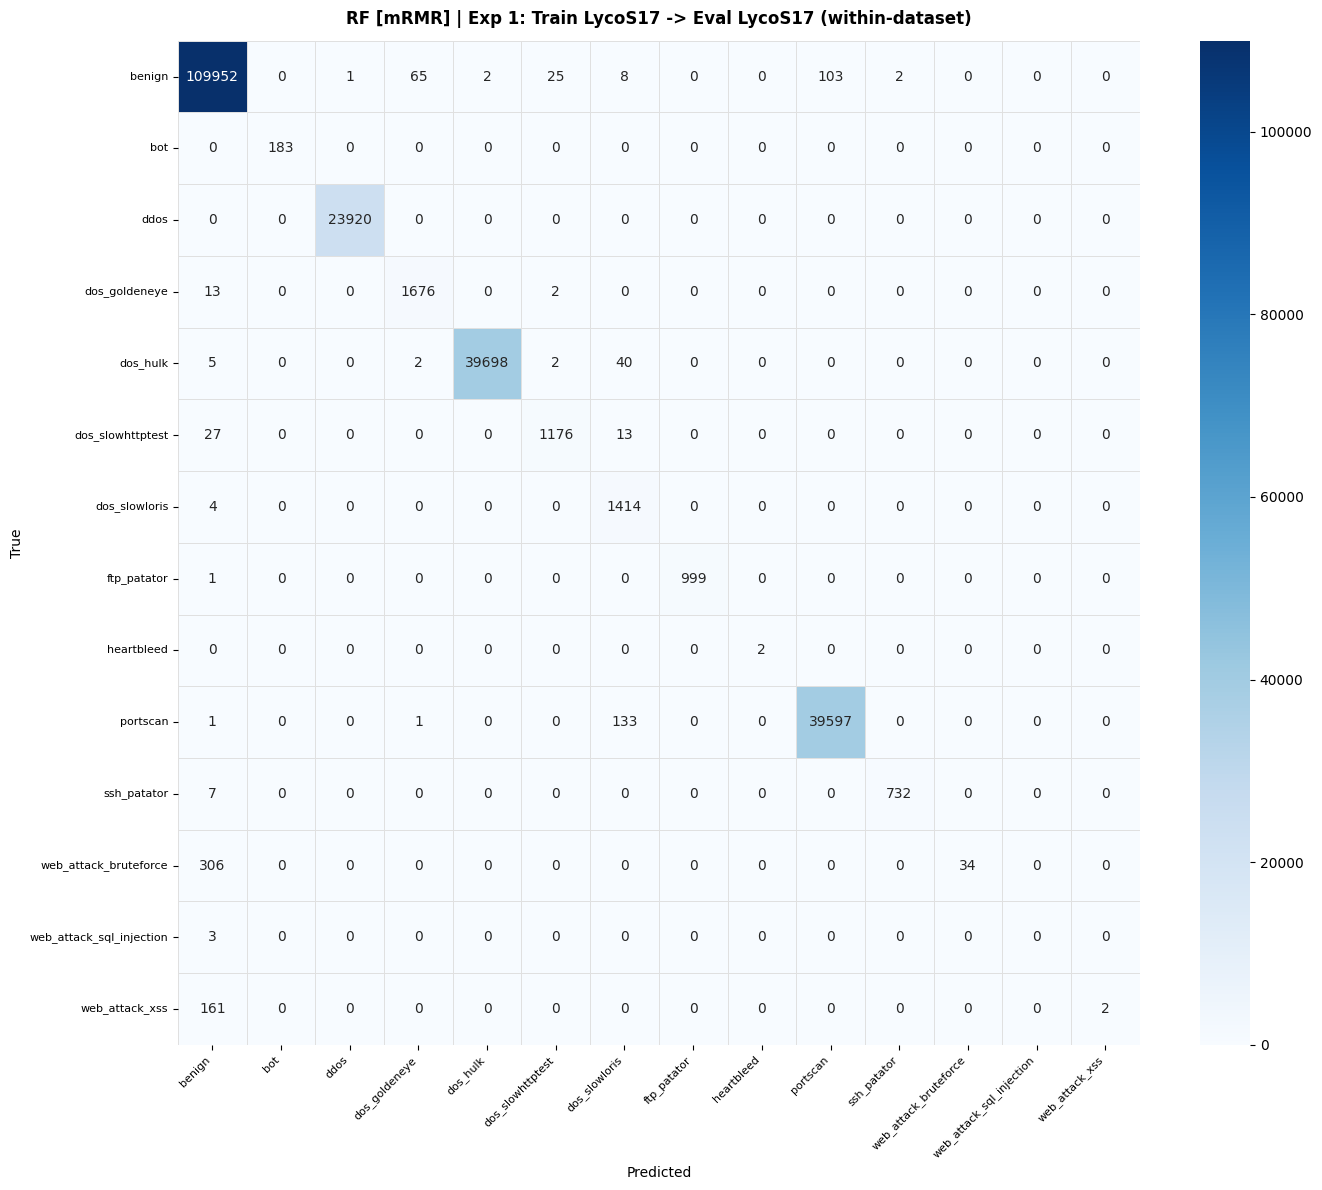


[XGBoost - grid search]
  Grid search on 100,000 / 660,944 rows (capped)
  Best params : {'booster': 'gbtree', 'gamma': 0, 'learning_rate': 0.3, 'max_depth': 12, 'min_child_weight': 0.5, 'n_estimators': 50}
  Best CV F1  : 0.8356

  XGB [mRMR] | Exp 1: Train LycoS17 -> Eval LycoS17 (within-dataset)
  MCC = 0.7092  |  Macro-F1 = 0.2292  |  AUROC = 0.6111
                          precision    recall  f1-score   support

                  benign       0.97      0.91      0.94    110158
                     bot       0.00      0.00      0.00       183
                    ddos       0.96      0.98      0.97     23920
           dos_goldeneye       0.00      0.00      0.00      1691
                dos_hulk       1.00      0.19      0.33     39747
        dos_slowhttptest       0.00      0.00      0.00      1216
           dos_slowloris       0.00      0.00      0.00      1418
             ftp_patator       0.00      0.00      0.00      1000
              heartbleed       0.00      0.00   

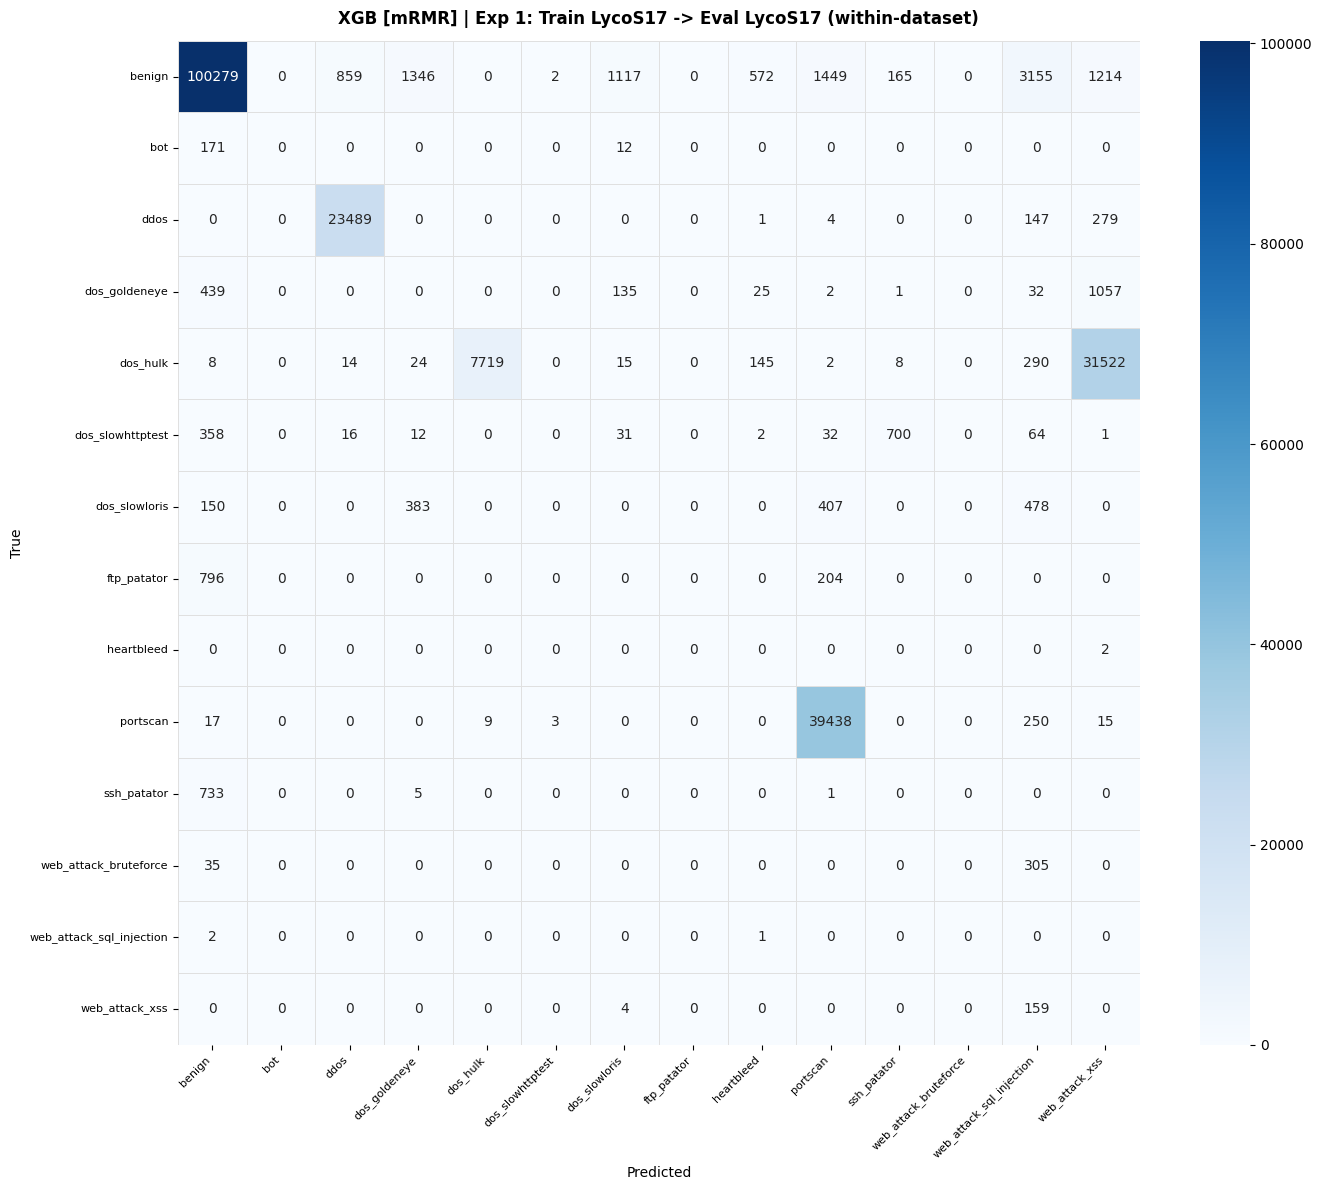


######################################################################
  EXPERIMENT 2 [mRMR + undersampling]: Train LycoS17 -> Eval LycoS18 (cross-dataset)
######################################################################

[Preprocessing]
  Undersampling: 468,959 -> 468,959 rows (benign=330,474, attack=138,485, ratio=2.4:1)
  Train: 468,959 rows | Test: 1,504,055 rows
  Features (10): ['pkt_len_mean', 'flag_rst', 'bwd_pkt_len_mean', 'active_min', 'pkt_len_std', 'bwd_pkt_len_max', 'pkt_len_max', 'bwd_pkt_len_std', 'fwd_pkt_hdr_len_min', 'down_up_ratio']
  Classes (10): ['benign', 'bot', 'dos_goldeneye', 'dos_hulk', 'dos_slowhttptest', 'dos_slowloris', 'ftp_patator', 'ssh_patator', 'web_attack_sql_injection', 'web_attack_xss']

[Random Forest - grid search]
  Grid search on 100,000 / 468,959 rows (capped)
  Best params : {'criterion': 'entropy', 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_split': 4, 'n_estimators': 50}
  Best CV F1  : 0.8192

  RF [mRMR] | Exp 2: Train Ly

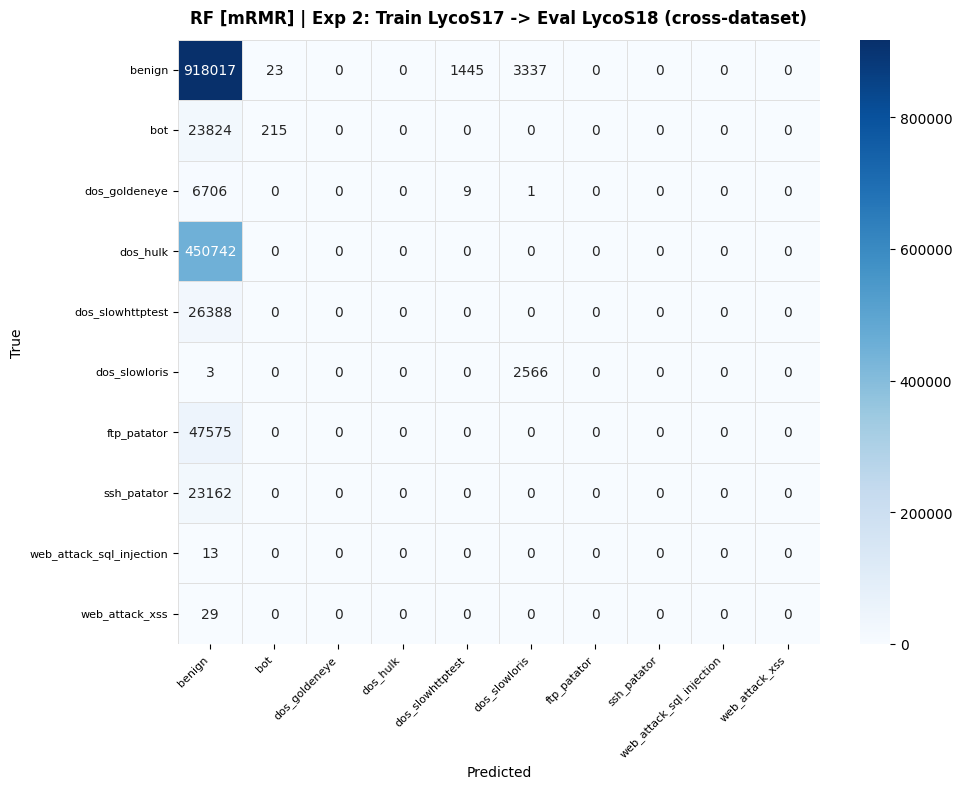


[XGBoost - grid search]
  Grid search on 100,000 / 468,959 rows (capped)
  Best params : {'booster': 'gbtree', 'gamma': 0, 'learning_rate': 0.1, 'max_depth': 12, 'min_child_weight': 0.5, 'n_estimators': 50}
  Best CV F1  : 0.8162

  XGB [mRMR] | Exp 2: Train LycoS17 -> Eval LycoS18 (cross-dataset)
  MCC = 0.1782  |  Macro-F1 = 0.2374  |  AUROC = 0.8761
                          precision    recall  f1-score   support

                  benign       0.62      0.99      0.77    922822
                     bot       0.00      0.00      0.00     24039
           dos_goldeneye       0.67      0.00      0.00      6716
                dos_hulk       0.00      0.00      0.00    450742
        dos_slowhttptest       0.00      0.00      0.00     26388
           dos_slowloris       0.44      1.00      0.61      2569
             ftp_patator       0.00      0.00      0.00     47575
             ssh_patator       1.00      1.00      1.00     23162
web_attack_sql_injection       0.00      0.00    

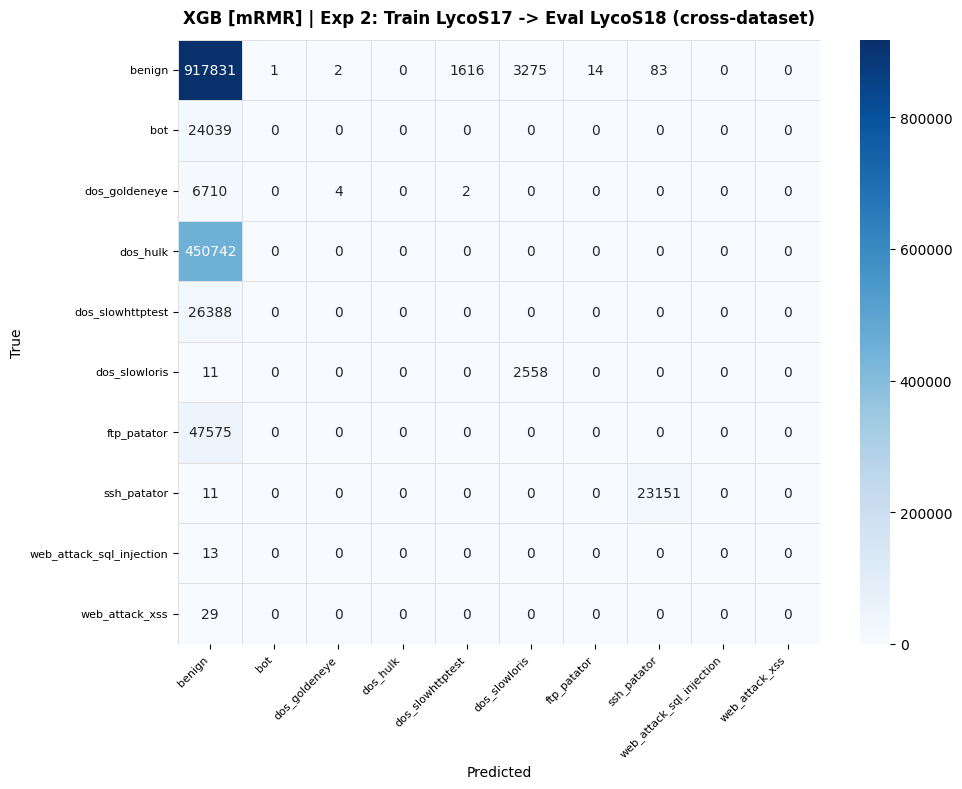


######################################################################
  EXPERIMENT 3 [mRMR + undersampling]: Train LycoS18 -> Eval LycoS18 (within-dataset)
######################################################################

[Preprocessing]
  Undersampling: 5,536,892 -> 5,536,892 rows (benign=2,768,446, attack=2,768,446, ratio=1.0:1)
  Train: 5,536,892 rows | Test: 1,845,644 rows
  Features (10): ['fwd_tcp_init_win_bytes', 'fwd_bulk_pkt_mean', 'pkt_per_s', 'fwd_non_empty_pkt_cnt', 'fwd_iat_min', 'bwd_pkt_hdr_len_min', 'fwd_subflow_pkt_mean', 'bwd_pkt_per_s', 'fwd_pkt_cnt', 'fwd_pkt_hdr_len_tot']
  Classes (14): ['benign', 'bot', 'ddos_hoic', 'ddos_loic_http', 'ddos_loic_udp', 'dos_goldeneye', 'dos_hulk', 'dos_slowhttptest', 'dos_slowloris', 'ftp_patator', 'ssh_patator', 'web_attack_brute_force', 'web_attack_sql_injection', 'web_attack_xss']

[Random Forest - grid search]
  Grid search on 100,000 / 5,536,892 rows (capped)
  Best params : {'criterion': 'entropy', 'max_depth': None, 

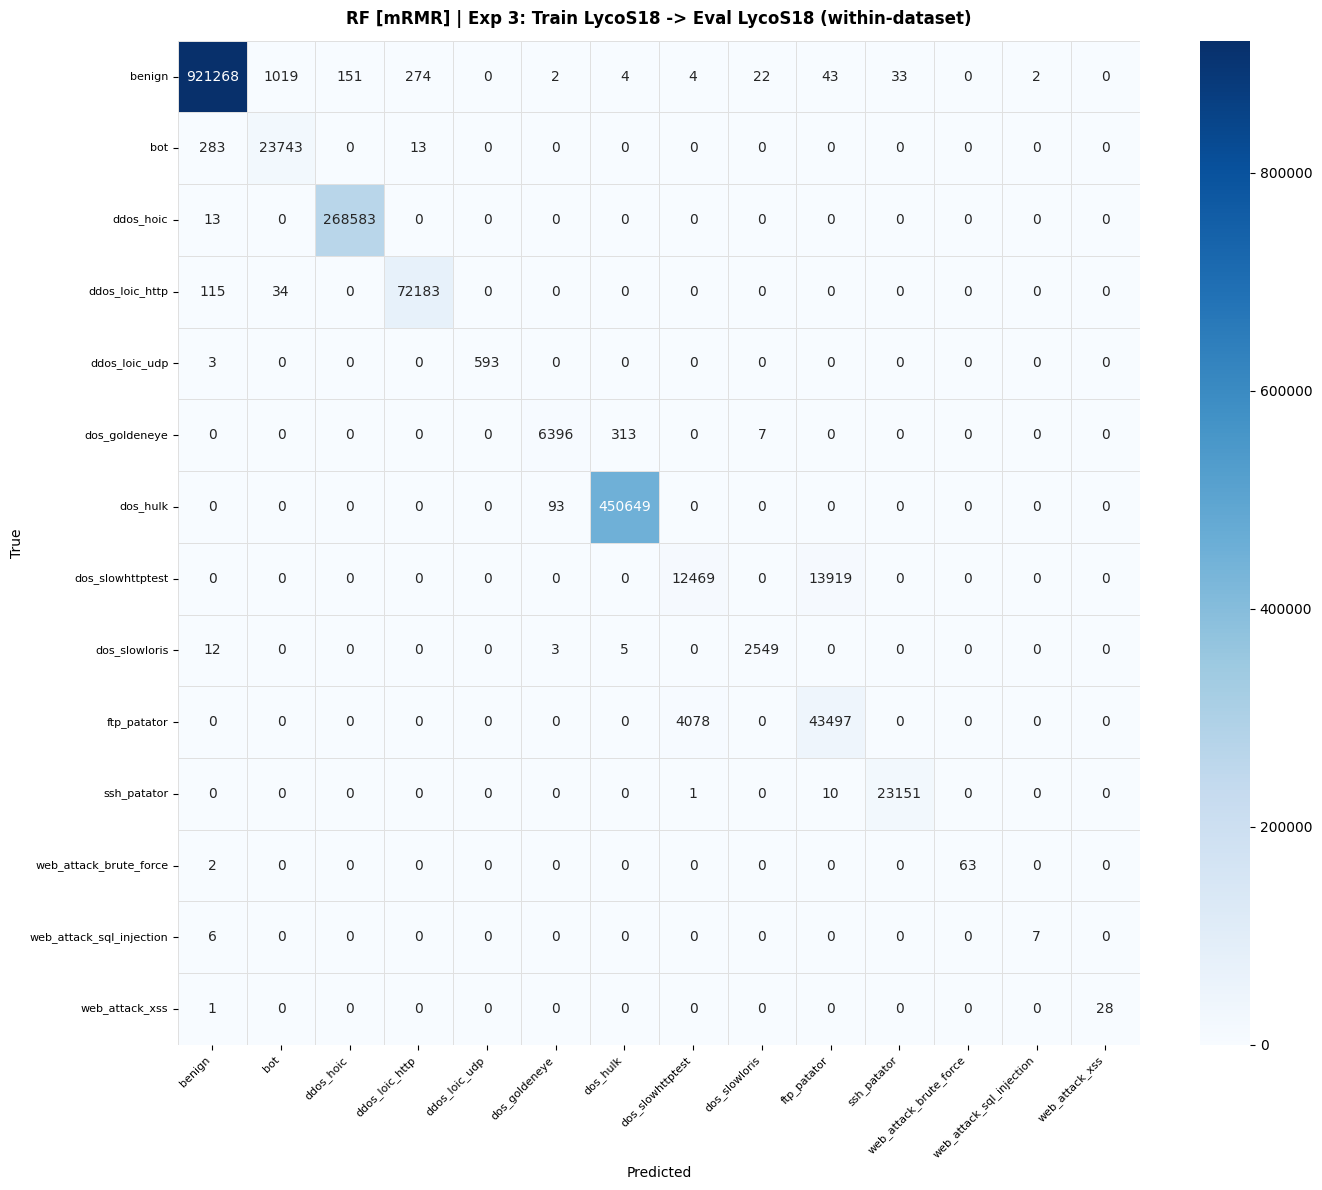


[XGBoost - grid search]
  Grid search on 100,000 / 5,536,892 rows (capped)
  Best params : {'booster': 'gbtree', 'gamma': 0, 'learning_rate': 0.1, 'max_depth': 3, 'min_child_weight': 0.5, 'n_estimators': 10}
  Best CV F1  : nan

  XGB [mRMR] | Exp 3: Train LycoS18 -> Eval LycoS18 (within-dataset)
  MCC = 0.9735  |  Macro-F1 = 0.7263  |  AUROC = 0.9907
                          precision    recall  f1-score   support

                  benign       0.99      1.00      0.99    922822
                     bot       0.96      0.94      0.95     24039
               ddos_hoic       1.00      1.00      1.00    268596
          ddos_loic_http       0.99      0.94      0.97     72332
           ddos_loic_udp       0.94      0.99      0.96       596
           dos_goldeneye       0.82      0.86      0.84      6716
                dos_hulk       1.00      1.00      1.00    450742
        dos_slowhttptest       0.67      0.47      0.55     26388
           dos_slowloris       0.90      0.10     

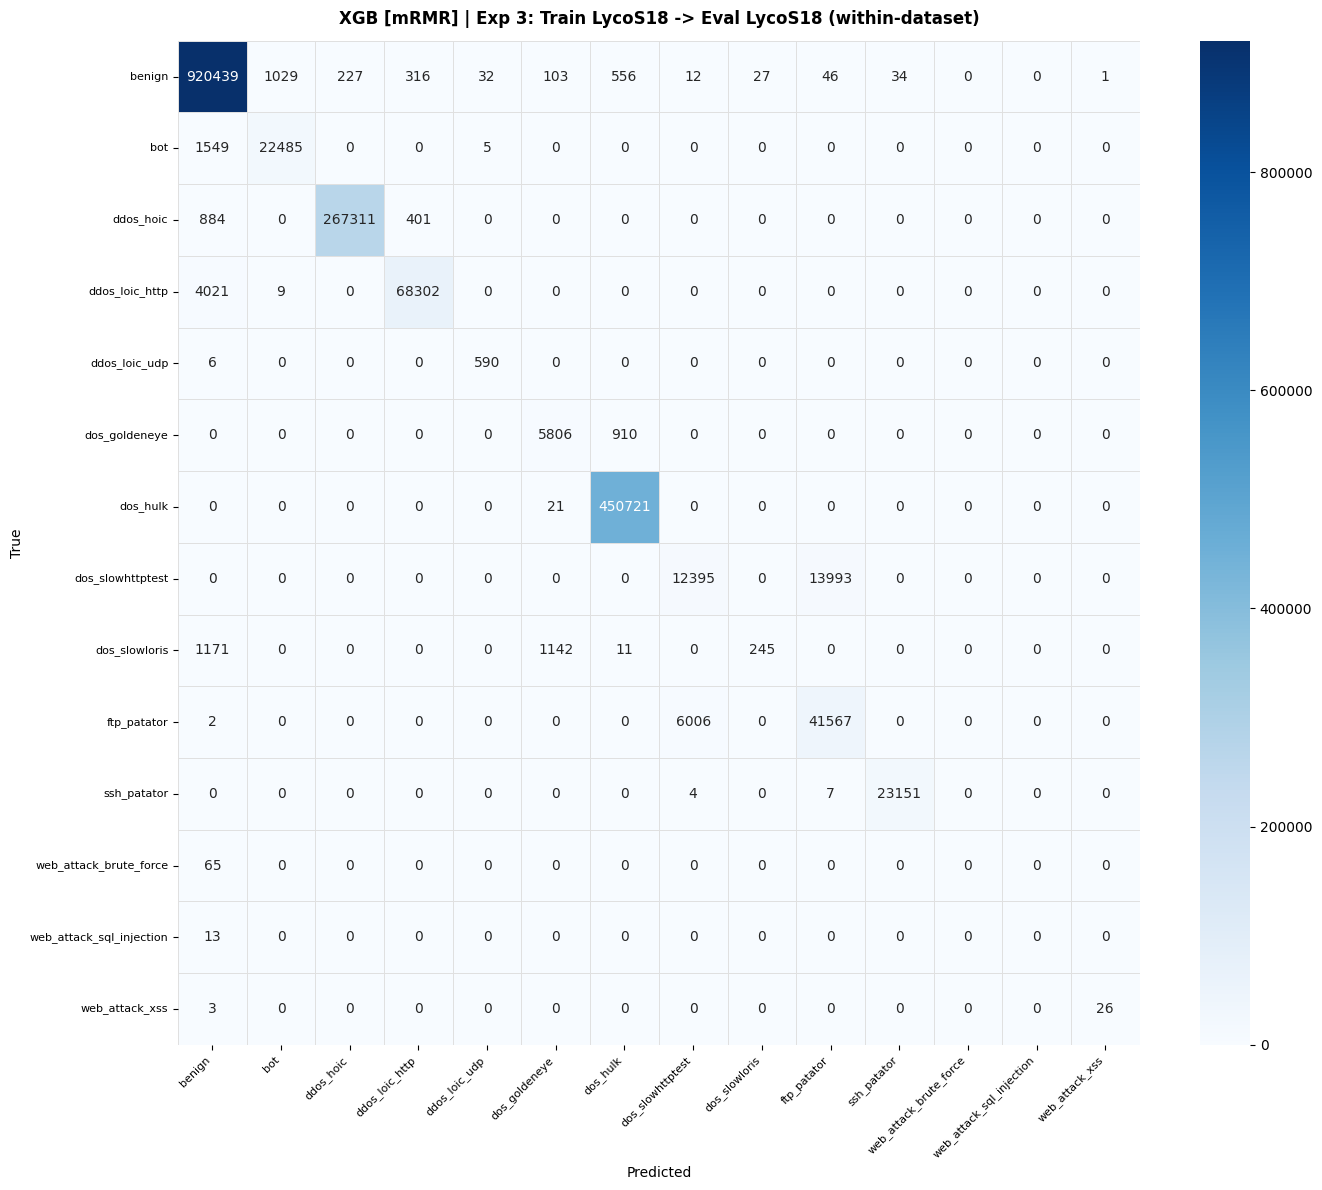


######################################################################
  EXPERIMENT 4 [mRMR + undersampling]: Train LycoS18 -> Eval LycoS17 (cross-dataset)
######################################################################

[Preprocessing]
  Undersampling: 4,512,132 -> 4,512,132 rows (benign=2,768,446, attack=1,743,686, ratio=1.6:1)
  Train: 4,512,132 rows | Test: 156,318 rows
  Features (10): ['fwd_tcp_init_win_bytes', 'fwd_bulk_pkt_mean', 'pkt_per_s', 'fwd_non_empty_pkt_cnt', 'fwd_iat_min', 'bwd_pkt_hdr_len_min', 'fwd_subflow_pkt_mean', 'bwd_pkt_per_s', 'fwd_pkt_cnt', 'fwd_pkt_hdr_len_tot']
  Classes (10): ['benign', 'bot', 'dos_goldeneye', 'dos_hulk', 'dos_slowhttptest', 'dos_slowloris', 'ftp_patator', 'ssh_patator', 'web_attack_sql_injection', 'web_attack_xss']

[Random Forest - grid search]
  Grid search on 100,000 / 4,512,132 rows (capped)
  Best params : {'criterion': 'gini', 'max_depth': None, 'max_features': None, 'min_samples_split': 4, 'n_estimators': 50}
  Best CV F1  

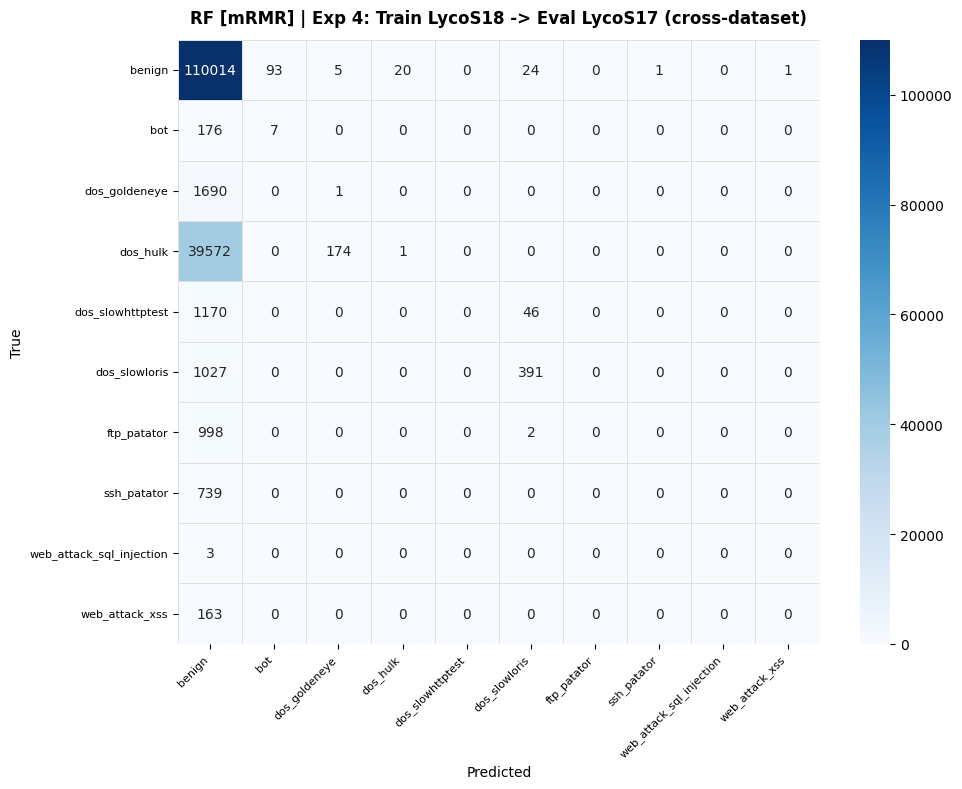


[XGBoost - grid search]
  Grid search on 100,000 / 4,512,132 rows (capped)
  Best params : {'booster': 'gbtree', 'gamma': 0, 'learning_rate': 0.1, 'max_depth': 6, 'min_child_weight': 0.5, 'n_estimators': 50}
  Best CV F1  : 0.8365

  XGB [mRMR] | Exp 4: Train LycoS18 -> Eval LycoS17 (cross-dataset)
  MCC = 0.1168  |  Macro-F1 = 0.1474  |  AUROC = 0.7720
                          precision    recall  f1-score   support

                  benign       0.71      1.00      0.83    110158
                     bot       0.03      0.01      0.02       183
           dos_goldeneye       0.00      0.00      0.00      1691
                dos_hulk       0.00      0.00      0.00     39747
        dos_slowhttptest       0.00      0.00      0.00      1216
           dos_slowloris       0.64      0.61      0.63      1418
             ftp_patator       0.00      0.00      0.00      1000
             ssh_patator       0.00      0.00      0.00       739
web_attack_sql_injection       0.00      0.00   

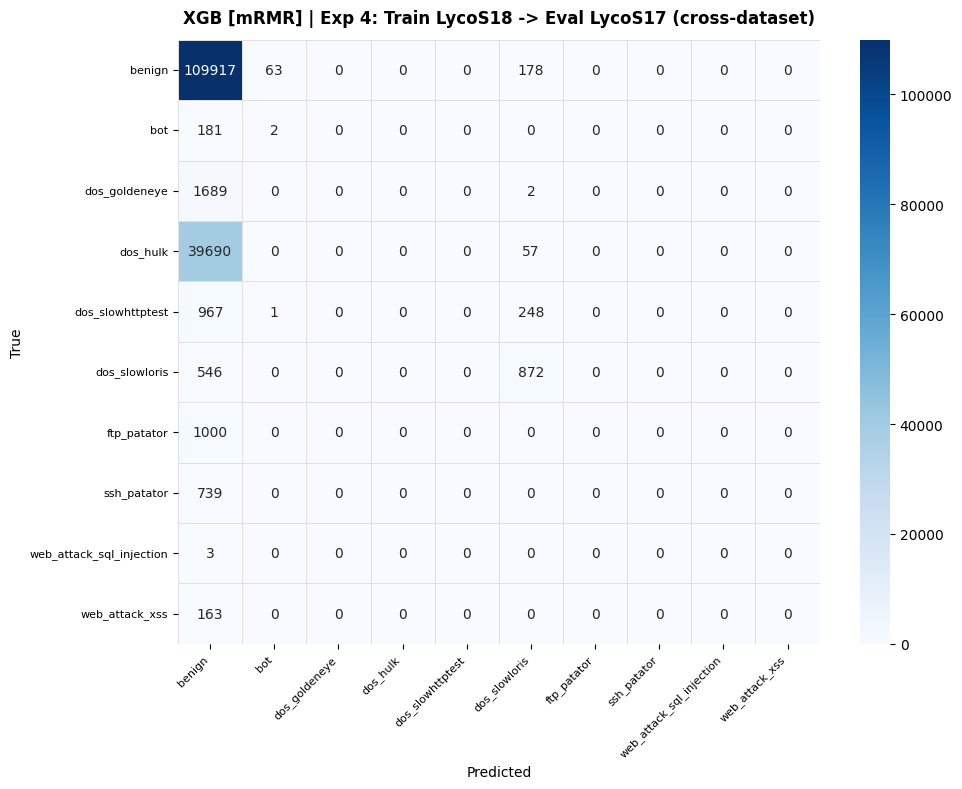


All mRMR experiments complete.


In [23]:
results_mrmr = []

for exp in EXPERIMENTS_MRMR:
    eid   = exp['id']
    title = exp['label']

    print(f'\n{"#"*70}')
    print(f'  EXPERIMENT {eid} [mRMR + undersampling]: {title}')
    print(f'{"#"*70}')

    # ── Preprocess ────────────────────────────────────────────────────────────
    print('\n[Preprocessing]')
    X_train, X_test, y_train, y_test, le = prepare_Xy_mrmr(
        train_df       = exp['train_df'],
        test_df        = exp['test_df'],
        features       = exp['features'],
        label_col      = LABEL_COL,
        shared_classes = exp['shared_classes'],
    )

    # ── Random Forest ─────────────────────────────────────────────────────────
    print('\n[Random Forest - grid search]')
    rf_base = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)
    rf_best = grid_search_fit(rf_base, RF_PARAM_GRID, X_train, y_train, cap=GRID_SEARCH_CAP_MRMR)

    rf_mcc, rf_f1, rf_auroc, rf_pred = evaluate(
        rf_best, X_test, y_test, le,
        title=f'RF [mRMR] | Exp {eid}: {title}',
    )
    plot_confusion_matrix(
        y_test, rf_pred, le,
        title=f'RF [mRMR] | Exp {eid}: {title}',
    )
    results_mrmr.append({
        'Experiment' : eid,
        'Description': title,
        'Model'      : 'RF',
        'MCC'        : rf_mcc,
        'Macro-F1'   : rf_f1,
        'AUROC': rf_auroc,
    })

    # ── XGBoost ───────────────────────────────────────────────────────────────
    print('\n[XGBoost - grid search]')
    xgb_base = XGBClassifier(
        random_state = RANDOM_STATE,
        eval_metric  = 'mlogloss',
        n_jobs       = -1,
        verbosity    = 0,
    )
    xgb_best = grid_search_fit(xgb_base, XGB_PARAM_GRID_MRMR, X_train, y_train, cap=GRID_SEARCH_CAP_MRMR)

    xgb_mcc, xgb_f1, xgb_auroc, xgb_pred = evaluate(
        xgb_best, X_test, y_test, le,
        title=f'XGB [mRMR] | Exp {eid}: {title}',
    )
    plot_confusion_matrix(
        y_test, xgb_pred, le,
        title=f'XGB [mRMR] | Exp {eid}: {title}',
    )
    results_mrmr.append({
        'Experiment' : eid,
        'Description': title,
        'Model'      : 'XGB',
        'MCC'        : xgb_mcc,
        'Macro-F1'   : xgb_f1,
        'AUROC': xgb_auroc,
    })

print('\nAll mRMR experiments complete.')

### 13.6 · Summary table — mRMR run

In [24]:
summary_mrmr = pd.DataFrame(results_mrmr)
summary_mrmr['Type'] = summary_mrmr['Experiment'].map({
    1: 'within-dataset',
    2: 'cross-dataset',
    3: 'within-dataset',
    4: 'cross-dataset',
})
summary_mrmr = (
    summary_mrmr[['Experiment', 'Type', 'Model', 'MCC', 'Macro-F1', 'AUROC', 'Description']]
    .sort_values(['Experiment', 'Model'])
    .reset_index(drop=True)
)
print(summary_mrmr.to_string(index=False))
summary_mrmr.to_csv('results_summary_mrmr.csv', index=False)
print('\nSaved to results_summary_mrmr.csv')

 Experiment           Type Model    MCC  Macro-F1  AUROC                                    Description
          1 within-dataset    RF 0.9937    0.7910 0.9638 Train LycoS17 -> Eval LycoS17 (within-dataset)
          1 within-dataset   XGB 0.7092    0.2292 0.6111 Train LycoS17 -> Eval LycoS17 (within-dataset)
          2  cross-dataset    RF 0.0236    0.1382 0.8194  Train LycoS17 -> Eval LycoS18 (cross-dataset)
          2  cross-dataset   XGB 0.1782    0.2374 0.8761  Train LycoS17 -> Eval LycoS18 (cross-dataset)
          3 within-dataset    RF 0.9834    0.9239 0.9889 Train LycoS18 -> Eval LycoS18 (within-dataset)
          3 within-dataset   XGB 0.9735    0.7263 0.9907 Train LycoS18 -> Eval LycoS18 (within-dataset)
          4  cross-dataset    RF 0.0767    0.1294 0.5248  Train LycoS18 -> Eval LycoS17 (cross-dataset)
          4  cross-dataset   XGB 0.1168    0.1474 0.7720  Train LycoS18 -> Eval LycoS17 (cross-dataset)

Saved to results_summary_mrmr.csv


### 13.7 · Side-by-side comparison: all features vs mRMR features

Compares MCC and Macro-F1 between the §9 baseline (all features, no undersampling)
and this run (mRMR features + undersampling) for each experiment and model.

In [25]:
# Merge the two summary tables on Experiment + Model
comparison = summary.merge(
    summary_mrmr,
    on=['Experiment', 'Type', 'Model', 'Description'],
    suffixes=('_all', '_mrmr'),
)

# Compute delta (mRMR run minus baseline)
comparison['ΔMCC']      = comparison['MCC_mrmr']      - comparison['MCC_all']
comparison['ΔMacro-F1'] = comparison['Macro-F1_mrmr'] - comparison['Macro-F1_all']
comparison['ΔAUROC'] = comparison['AUROC_mrmr'] - comparison['AUROC_all']

display_cols = [
    'Experiment', 'Type', 'Model',
    'MCC_all',      'MCC_mrmr',      'ΔMCC',
    'Macro-F1_all', 'Macro-F1_mrmr', 'ΔMacro-F1',
    'AUROC_all',    'AUROC_mrmr',    'ΔAUROC',
]

print(comparison[display_cols].to_string(index=False))
comparison[display_cols].to_csv('results_comparison.csv', index=False)
print('\nSaved to results_comparison.csv')

 Experiment           Type Model  MCC_all  MCC_mrmr    ΔMCC  Macro-F1_all  Macro-F1_mrmr  ΔMacro-F1  AUROC_all  AUROC_mrmr  ΔAUROC
          1 within-dataset    RF   0.9978    0.9937 -0.0040        0.8610         0.7910    -0.0699     0.9836      0.9638 -0.0198
          1 within-dataset   XGB   0.9928    0.7092 -0.2836        0.7350         0.2292    -0.5058     0.9957      0.6111 -0.3845
          2  cross-dataset    RF   0.0427    0.0236 -0.0191        0.2355         0.1382    -0.0972     0.7914      0.8194  0.0280
          2  cross-dataset   XGB   0.0313    0.1782  0.1469        0.1355         0.2374     0.1019     0.9383      0.8761 -0.0622
          3 within-dataset    RF   0.9841    0.9834 -0.0007        0.9273         0.9239    -0.0033     0.9993      0.9889 -0.0104
          3 within-dataset   XGB   0.9832    0.9735 -0.0097        0.7830         0.7263    -0.0567     0.9979      0.9907 -0.0072
          4  cross-dataset    RF   0.1318    0.0767 -0.0552        0.1774         0

### 13.8 · Comparison bar chart

Saved: comparison_mcc.png


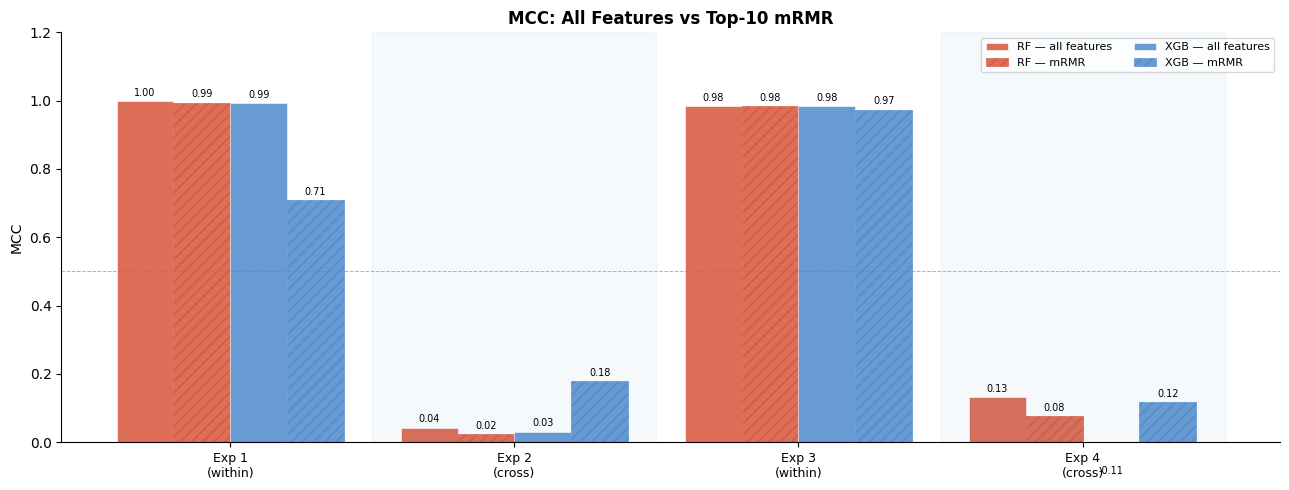

Saved: comparison_macro_f1.png


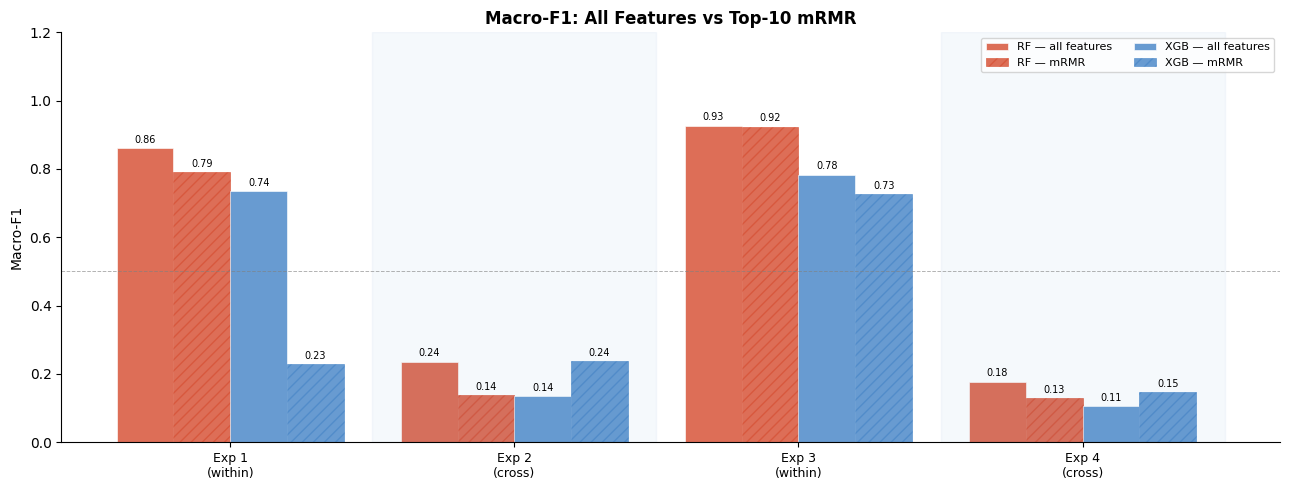

Saved: comparison_auroc.png


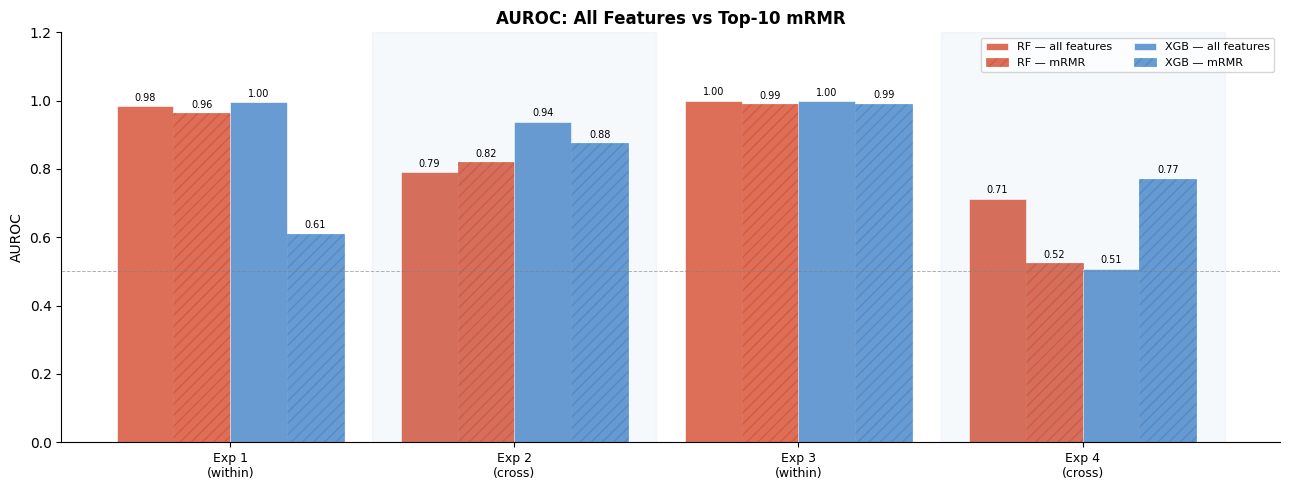

In [28]:
def plot_comparison_bar(comparison, metric, title):
    """
    Grouped bar chart comparing all-features vs mRMR for one metric.
    One group per experiment, two bars per model (RF and XGB),
    hatched bars = mRMR run.
    """
    models   = ['RF', 'XGB']
    exp_ids  = sorted(comparison['Experiment'].unique())
    n_exp    = len(exp_ids)
    n_models = len(models)
    bar_w    = 0.2
    x        = np.arange(n_exp)

    # Colour per model, hatch distinguishes all-features vs mRMR
    MODEL_COLOURS = {'RF': '#D7553A', 'XGB': '#4E8AC9'}

    fig, ax = plt.subplots(figsize=(13, 5))

    offsets = np.linspace(
        -(n_models - 0.5) * bar_w,
         (n_models - 0.5) * bar_w,
        n_models * 2
    )

    bar_idx = 0
    legend_handles = []

    for model in models:
        colour = MODEL_COLOURS[model]

        for run_suffix, hatch, run_label in [
            (f'{metric}_all',  '',    'all features'),
            (f'{metric}_mrmr', '///', 'mRMR'),
        ]:
            vals = []
            for eid in exp_ids:
                row = comparison[
                    (comparison['Experiment'] == eid) &
                    (comparison['Model'] == model)
                ]
                vals.append(row[run_suffix].values[0] if len(row) else 0.0)

            bars = ax.bar(
                x + offsets[bar_idx], vals, bar_w,
                color=colour, hatch=hatch,
                edgecolor='white' if not hatch else colour,
                linewidth=0.5, alpha=0.85,
                label=f'{model} — {run_label}',
            )
            for bar, val in zip(bars, vals):
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.01,
                    f'{val:.2f}',
                    ha='center', va='bottom', fontsize=7,
                )
            bar_idx += 1

    exp_labels = [
        f'Exp {eid}\n({"within" if eid in (1,3) else "cross"})'
        for eid in exp_ids
    ]

    # Shade cross-dataset groups
    for xi, eid in enumerate(exp_ids):
        if eid in (2, 4):
            ax.axvspan(xi - 0.5, xi + 0.5, alpha=0.05, color='#4E8AC9')

    ax.axhline(0.5, color='grey', linewidth=0.7, linestyle='--', alpha=0.6)
    ax.set_xticks(x)
    ax.set_xticklabels(exp_labels, fontsize=9)
    ax.set_ylim(0, 1.2)
    ax.set_ylabel(metric, fontsize=10)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.spines[['top', 'right']].set_visible(False)
    ax.legend(fontsize=8, ncol=2, loc='upper right')

    plt.tight_layout()
    fname = f'comparison_{metric.lower().replace("-","_")}.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    print(f'Saved: {fname}')
    plt.show()


plot_comparison_bar(
    comparison, 'MCC',
    f'MCC: All Features vs Top-{TOP_N_FEATURES} mRMR'
)
plot_comparison_bar(
    comparison, 'Macro-F1',
    f'Macro-F1: All Features vs Top-{TOP_N_FEATURES} mRMR'
)
plot_comparison_bar(
    comparison, 'AUROC',
    f'AUROC: All Features vs Top-{TOP_N_FEATURES} mRMR'
)